# Bab III — Metodologi Penelitian

Notebook ini mendokumentasikan seluruh pipeline eksperimen klasifikasi citra makanan berbasis **EfficientNetV2B0** pada dataset **Food-101**:

1. **Persiapan environment & dataset** — mount Google Drive, ekstrak arsip ke SSD lokal Colab untuk throughput I/O maksimal.
2. **Data loading pipeline** — pembagian *train/val/test* mengikuti **split resmi Food-101** (`meta/train.txt` + `meta/test.txt`), dengan validasi 10% distratifikasi dari train.
3. **Arsitektur model** — EfficientNetV2B0 *pretrained ImageNet* dengan *classification head* (GAP → BN → Dropout → Dense 101).
4. **Strategi training dua-tahap (two-stage fine-tuning)** — Stage 1 *frozen backbone* untuk memanaskan head, Stage 2 *unfrozen* dengan `WarmUpCosine` LR schedule.
5. **Evaluasi** — akurasi Top-1, Top-5, *precision/recall/F1* (macro & weighted), *confusion matrix* 101×101, peringkat akurasi per-kelas.
6. **Deployment** — konversi ke TensorFlow.js (quantisasi float16) untuk inferensi real-time di browser.


In [ ]:
# @title 1. Setup Environment, Hardware, Path & Ekstrak Dataset
import sys
import os
import gzip
import shutil
import tarfile
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from tensorflow.keras import mixed_precision

# Setup tampilan Pandas agar tabel rapi
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)

# --- A. Mount Drive ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- B. Setup Path ---
# Arsip dataset (.tar.gz) + output model tetap di Drive agar PERSISTEN
BASE_DIR = '/content/drive/MyDrive/Skripsi/Deep_Learning'
MODELS_DIR = os.path.join(BASE_DIR, 'models')
TARGZ_PATH = os.path.join(BASE_DIR, 'food-101.tar.gz')

# Hasil ekstrak dataset disimpan di SSD Lokal Google Colab (I/O sangat cepat)
# Membaca 101.000 gambar dari Drive akan jauh lebih lambat (bottleneck network).
LOCAL_ROOT = '/content'
TAR_PATH = os.path.join(LOCAL_ROOT, 'food-101.tar')
DATASET_PATH = os.path.join(LOCAL_ROOT, 'food-101')
IMAGE_DIR = os.path.join(DATASET_PATH, 'images')
META_DIR = os.path.join(DATASET_PATH, 'meta')

# Buat folder models di Drive jika belum ada
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

print(f"📂 BASE DIR (Drive)         : {BASE_DIR}")
print(f"📦 ARSIP .tar.gz (Drive)    : {TARGZ_PATH}")
print(f"💾 DATASET DIR (SSD Lokal)  : {DATASET_PATH}")
print(f"🗄️ MODELS DIR (Drive)       : {MODELS_DIR}")

# --- C. Ekstrak Dataset ke SSD Lokal Colab ---
def extract_dataset():
    """
    Alur:
      1. food-101.tar.gz (di Drive)  --(gunzip)-->  /content/food-101.tar
      2. /content/food-101.tar       --(untar)-->   /content/food-101/{images,meta}/
    Hasil akhir: dataset berada di SSD lokal Colab, BUKAN di Drive.
    """
    # Skip jika dataset sudah diekstrak penuh di SSD lokal
    if os.path.exists(IMAGE_DIR) and len(os.listdir(IMAGE_DIR)) >= 101:
        num_folders = len(os.listdir(IMAGE_DIR))
        print(f"\n✅ Dataset sudah tersedia di SSD lokal: {IMAGE_DIR}")
        print(f"📊 Jumlah Kelas Terdeteksi: {num_folders}")
        return

    # Validasi arsip .tar.gz ada di Drive
    if not os.path.exists(TARGZ_PATH):
        raise FileNotFoundError(
            f"❌ Arsip tidak ditemukan: {TARGZ_PATH}\n"
            f"   Pastikan food-101.tar.gz sudah diupload ke {BASE_DIR}"
        )

    # Step 1: Ekstrak .tar.gz -> .tar (di SSD lokal)
    if not os.path.exists(TAR_PATH):
        print(f"\n📦 [1/2] Ekstrak .tar.gz -> .tar di SSD lokal Colab...")
        print(f"   Source : {TARGZ_PATH}")
        print(f"   Target : {TAR_PATH}")
        with gzip.open(TARGZ_PATH, 'rb') as f_in:
            with open(TAR_PATH, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out, length=16 * 1024 * 1024)
        print(f"✅ Selesai: {TAR_PATH} ({os.path.getsize(TAR_PATH) / (1024**3):.2f} GB)")
    else:
        print(f"\n📦 [1/2] .tar sudah ada di SSD lokal: {TAR_PATH}")

    # Step 2: Ekstrak .tar -> folder food-101/ (di SSD lokal)
    print(f"\n📦 [2/2] Ekstrak .tar -> {DATASET_PATH} (SSD lokal)...")
    with tarfile.open(TAR_PATH, 'r') as tar:
        tar.extractall(path=LOCAL_ROOT)
    print(f"✅ Ekstraksi selesai di SSD lokal.")

    # Hapus file .tar perantara untuk hemat ruang SSD
    try:
        os.remove(TAR_PATH)
        print(f"🧹 File perantara dihapus: {TAR_PATH}")
    except Exception as e:
        print(f"⚠️ Gagal hapus .tar: {e}")

    # Validasi hasil
    if os.path.exists(IMAGE_DIR):
        num_folders = len(os.listdir(IMAGE_DIR))
        print(f"\n✅ Dataset siap di SSD lokal: {IMAGE_DIR}")
        print(f"📊 Jumlah Kelas Terdeteksi: {num_folders}")
    else:
        print(f"❌ ERROR: {IMAGE_DIR} tidak ditemukan setelah ekstraksi.")

extract_dataset()

# --- D. Hardware Check & Optimization ---
def setup_hardware():
    print("\n🚀 MEMERIKSA HARDWARE & KONFIGURASI...")
    try:
        # Mixed Precision untuk efisiensi tinggi (Mempercepat training)
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed Precision Aktif: {policy.compute_dtype}")

        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv,noheader
                print(f"✅ GPU Terdeteksi: {gpu_name[0]}")
            except:
                print("✅ GPU Terdeteksi (Detail nama tidak dapat diambil)")
            strategy = tf.distribute.MirroredStrategy()
        else:
            print("⚠️ GPU Tidak Terdeteksi. Training akan sangat lambat.")
            strategy = tf.distribute.get_strategy()
    except Exception as e:
        print(f"⚠️ Warning pada setup GPU: {e}")
        strategy = tf.distribute.get_strategy()

    print("\n🔰 SISTEM SIAP.")
    return strategy

strategy = setup_hardware()


📂 BASE DIR (Drive)         : /content/drive/MyDrive/Skripsi/Deep_Learning
📦 ARSIP .tar.gz (Drive)    : /content/drive/MyDrive/Skripsi/Deep_Learning/food-101.tar.gz
💾 DATASET DIR (SSD Lokal)  : /content/food-101
🗄️ MODELS DIR (Drive)       : /content/drive/MyDrive/Skripsi/Deep_Learning/models

📦 [1/2] Ekstrak .tar.gz -> .tar di SSD lokal Colab...
   Source : /content/drive/MyDrive/Skripsi/Deep_Learning/food-101.tar.gz
   Target : /content/food-101.tar


In [ ]:
# @title 2. Data Loading Pipeline (Split Resmi Food-101)
import tensorflow as tf
import os
import random
from sklearn.model_selection import train_test_split

# --- KONFIGURASI ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

# Reprodusibilitas: set seed global
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"⚙️ PIPELINE CONFIG:")
print(f"   Image Size : {IMG_SIZE}")
print(f"   Batch Size : {BATCH_SIZE}")
print(f"   Seed       : {SEED}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Folder images tidak ditemukan di: {IMAGE_DIR}")

# --- A. BACA SPLIT RESMI FOOD-101 (meta/train.txt & meta/test.txt) ---
def load_split(split_file):
    """Baca file split resmi. Format tiap baris: 'apple_pie/1005649' (tanpa .jpg)."""
    path = os.path.join(META_DIR, split_file)
    with open(path, 'r') as f:
        entries = [line.strip() for line in f if line.strip()]
    file_paths = [os.path.join(IMAGE_DIR, e + '.jpg') for e in entries]
    labels = [e.split('/')[0] for e in entries]
    return file_paths, labels

print("\n📂 Membaca split resmi Food-101...")
train_paths_full, train_labels_full = load_split('train.txt')
test_paths, test_labels_str = load_split('test.txt')
print(f"   train.txt : {len(train_paths_full):>6} sampel")
print(f"   test.txt  : {len(test_paths):>6} sampel")

# --- B. DAFTAR KELAS (urutan alfabet, konsisten dengan standar Keras) ---
loaded_class_names = sorted(set(train_labels_full))
num_classes = len(loaded_class_names)
class_to_idx = {c: i for i, c in enumerate(loaded_class_names)}
print(f"📊 Total Kelas : {num_classes}")

# Konversi label string → indeks integer
train_labels_full_idx = [class_to_idx[l] for l in train_labels_full]
test_labels = [class_to_idx[l] for l in test_labels_str]

# --- C. PISAH: TRAIN 90% + VAL 10% (STRATIFIED) ---
# Val HANYA dari train.txt → test.txt benar-benar held-out untuk evaluasi final
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_full, train_labels_full_idx,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels_full_idx
)
print(f"\n📦 HASIL SPLIT FINAL:")
print(f"   Train : {len(train_paths):>6} sampel  (90% dari train.txt)")
print(f"   Val   : {len(val_paths):>6} sampel  (10% dari train.txt → EarlyStopping/Checkpoint)")
print(f"   Test  : {len(test_paths):>6} sampel  (test.txt → HELD-OUT, hanya evaluasi final)")

# --- D. VALIDASI INTEGRITAS DATASET ---
# Cegah crash mid-training karena file korup / ekstraksi tidak sempurna
print("\n🔍 Validasi Integritas Dataset Food-101...")
EXPECTED_TRAIN = 75750
EXPECTED_TEST = 25250
EXPECTED_CLASSES = 101

assert len(train_paths_full) == EXPECTED_TRAIN, \
    f"train.txt harus {EXPECTED_TRAIN} sampel, ditemukan {len(train_paths_full)}"
assert len(test_paths) == EXPECTED_TEST, \
    f"test.txt harus {EXPECTED_TEST} sampel, ditemukan {len(test_paths)}"
assert num_classes == EXPECTED_CLASSES, \
    f"Jumlah kelas harus {EXPECTED_CLASSES}, ditemukan {num_classes}"

# Spot-check 5 file acak (3 train, 1 val, 1 test) benar-benar ada di disk
_check_paths = (
    random.sample(train_paths, 3)
    + random.sample(val_paths, 1)
    + random.sample(test_paths, 1)
)
for p in _check_paths:
    assert os.path.exists(p), f"File tidak ditemukan: {p}"

print(f"   ✅ Jumlah sampel   : {EXPECTED_TRAIN} train + {EXPECTED_TEST} test — SESUAI")
print(f"   ✅ Jumlah kelas    : {EXPECTED_CLASSES} — SESUAI")
print(f"   ✅ Spot-check 5 file acak: OK (semua ada di disk)")

# --- E. tf.data PIPELINE ---
AUTOTUNE = tf.data.AUTOTUNE

def _load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    label_onehot = tf.one_hot(label, num_classes)
    return img, label_onehot

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000),
                        seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

print("\n🔄 Membangun tf.data pipeline...")
train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  shuffle=False)
print("✅ Pipeline siap: train_ds, val_ds, test_ds")


In [ ]:
# @title 3. Visualisasi Sampel Dataset
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(12, 12))
plt.suptitle("Sampel Dataset Food-101", fontsize=16, y=0.92)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = image_batch[i].numpy().astype("uint8")
    plt.imshow(img)

    label_index = np.argmax(label_batch[i])
    class_name = loaded_class_names[label_index].replace("_", " ").title()

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
# @title 4. Membangun Model Arsitektur (EfficientNetV2B0)
import tensorflow as tf

def build_model(num_classes):
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))

    # Augmentasi Ringan (hanya aktif saat training=True)
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)

    # Base Model (EfficientNetV2B0, pretrained ImageNet)
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )

    # Stage 1: FREEZE backbone → hanya head yang dilatih (transfer learning)
    # Akan di-unfreeze pada Stage 2 untuk fine-tuning end-to-end
    base_model.trainable = False

    # Classification Head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    full_model = tf.keras.Model(inputs, outputs, name="EfficientNetV2B0_Food101")
    return full_model, base_model

with strategy.scope():
    model, base_model = build_model(num_classes)

# Info params
total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
frozen_params = total_params - trainable_params

print(f"✅ Model Arsitektur EfficientNetV2B0 Berhasil Dibangun untuk {num_classes} kelas.")
print(f"   - Total parameters       : {total_params:>12,}")
print(f"   - Trainable (Stage 1)    : {trainable_params:>12,}  (hanya head: BN + Dense)")
print(f"   - Frozen  (backbone)     : {frozen_params:>12,}  (di-unfreeze di Stage 2)")
model.summary(expand_nested=False, show_trainable=True)


## 3.5 Strategi Training — Stage 1: Transfer Learning (Frozen Backbone)

Stage pertama men-*freeze* seluruh backbone EfficientNetV2B0 (± 5,9 juta parameter) sehingga hanya *classification head* (BN + Dense 101) yang dilatih. Tujuannya adalah memberi head kesempatan "memanaskan" bobot acaknya dengan *learning rate* konstan yang relatif besar (`1e-3`) tanpa merusak fitur konvolusional hasil pretraining ImageNet. Tahap ini hanya butuh sedikit epoch (5) karena yang dioptimasi sangat sedikit.


In [ ]:
# @title 5. Optimizer & LR Scheduler — Stage 1: Frozen Backbone
import tensorflow as tf
import numpy as np

# --- A. WarmUpCosine LR Schedule (dipakai di Stage 2) ---
@tf.keras.utils.register_keras_serializable()
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total steps must be larger than warmup steps")
        lr = 0.5 * self.learning_rate_base * (1 + tf.cos(
            self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)))
        if self.warmup_steps > 0:
            slope = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)

    def get_config(self):
        return {
            'learning_rate_base': self.learning_rate_base,
            'total_steps': self.total_steps,
            'warmup_learning_rate': self.warmup_learning_rate,
            'warmup_steps': self.warmup_steps,
        }

# --- B. LearningRateLogger (catat LR efektif per epoch ke CSV) ---
class LearningRateLogger(tf.keras.callbacks.Callback):
    """Injeksi field 'lr' ke logs agar tercatat di CSVLogger."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if callable(lr):
            lr = lr(self.model.optimizer.iterations)
        logs['lr'] = float(tf.keras.backend.get_value(lr))

# --- C. Konfigurasi strategi two-stage fine-tuning ---
# Budget dinaikkan dari 15 → 50 epoch agar model tidak underfitting. EarlyStopping pada
# Stage 2 bertindak sebagai "rem otomatis" — memotong training bila val_accuracy
# sudah plateau, sehingga risiko overfitting tetap terkendali meski budget besar.
STAGE1_EPOCHS = 5        # Transfer learning: backbone frozen, hanya head dilatih (warm-up cepat)
STAGE2_EPOCHS = 45       # Fine-tuning end-to-end: budget besar; EarlyStopping (patience=8) memotong bila val_accuracy plateau
TOTAL_EPOCHS  = STAGE1_EPOCHS + STAGE2_EPOCHS   # Total 50 epoch (5 + 45)

print(f"🎯 TWO-STAGE FINE-TUNING STRATEGY")
print(f"   Stage 1 (Frozen)    : {STAGE1_EPOCHS} epoch → head only, LR konstan 1e-3")
print(f"   Stage 2 (Unfrozen)  : {STAGE2_EPOCHS} epoch → end-to-end, WarmUpCosine (base=1e-4) + EarlyStopping")
print(f"   Total budget        : {TOTAL_EPOCHS} epoch (EarlyStopping dapat menghentikan lebih awal bila val_accuracy plateau)")

# --- D. Compile Stage 1 — LR konstan, backbone masih frozen (dari Cell 4) ---
STAGE1_LR = 1e-3
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=STAGE1_LR, weight_decay=2e-5),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
        ],
        jit_compile=False,
    )

print(f"\n✅ Stage 1 compile selesai — LR = {STAGE1_LR}, jit_compile=False")
print(f"   Metrics: Accuracy, Top-5 Accuracy")


In [ ]:
# @title 6. Training Stage 1 — Transfer Learning (Frozen Backbone)
import os
import tensorflow as tf

checkpoint_path  = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')
log_path         = os.path.join(MODELS_DIR, 'training_log.csv')

callbacks_s1 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1,
    ),
    LearningRateLogger(),
    tf.keras.callbacks.CSVLogger(log_path, append=False),
]

train_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"🚀 STAGE 1 TRAINING — {STAGE1_EPOCHS} epoch (backbone FROZEN, head only)")
print(f"   Trainable params: {train_params:,}")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    callbacks=callbacks_s1,
    verbose=1,
)
print("\n✅ Stage 1 selesai.")

## 3.6 Strategi Training — Stage 2: Fine-Tuning End-to-End (Unfrozen Backbone)

Stage kedua me-*unfreeze* seluruh backbone dan melatih model end-to-end selama maksimum **45 epoch** (total 50 epoch bersama Stage 1) dengan *learning rate* jauh lebih kecil (`base=1e-4`) mengikuti skema `WarmUpCosine` (warm-up 10% steps → cosine decay ke 0 sepanjang 45 epoch). LR yang kecil menjaga agar fitur pretrained tidak rusak, sementara *cosine decay* yang “direntangkan” memastikan model tetap belajar di epoch-epoch akhir alih-alih membeku terlalu cepat seperti pada skema 10-epoch sebelumnya.

`EarlyStopping` (`monitor='val_accuracy'`, `patience=8`, `min_delta=0.001`, `restore_best_weights=True`) bertindak sebagai “rem otomatis”: jika akurasi validasi tidak meningkat ≥ 0.1% selama 8 epoch berturut-turut, training dihentikan dan bobot terbaik dipulihkan. Kombinasi budget besar + EarlyStopping + checkpoint terbaik memberi model cukup ruang untuk belajar tanpa risiko *overfitting*.


In [ ]:
# @title 6b. Training Stage 2 — Fine-Tuning End-to-End (Unfrozen Backbone)
import os
import tensorflow as tf

# --- A. Unfreeze backbone EfficientNetV2B0 ---
base_model.trainable = True
train_params_s2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"🔓 Backbone di-UNFREEZE untuk fine-tuning end-to-end.")
print(f"   Trainable params: {train_params_s2:,}")

# --- B. Recompile dengan WarmUpCosine LR schedule (LR kecil agar tidak merusak fitur pretrained) ---
steps_per_epoch = len(train_ds)
TOTAL_STEPS_S2  = int(steps_per_epoch * STAGE2_EPOCHS)
WARMUP_STEPS_S2 = int(TOTAL_STEPS_S2 * 0.1)

lr_schedule_s2 = WarmUpCosine(
    learning_rate_base=1e-4,
    total_steps=TOTAL_STEPS_S2,
    warmup_learning_rate=1e-6,
    warmup_steps=WARMUP_STEPS_S2,
)

with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule_s2, weight_decay=2e-5),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
        ],
        jit_compile=False,
    )
print(f"✅ Stage 2 compile selesai — WarmUpCosine (base=1e-4, warmup={WARMUP_STEPS_S2}/{TOTAL_STEPS_S2} steps)")

# --- C. Callbacks Stage 2 (CSV append=True agar melanjutkan log Stage 1) ---
checkpoint_path = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')
log_path        = os.path.join(MODELS_DIR, 'training_log.csv')

callbacks_s2 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1,
    ),
    # EarlyStopping: "rem otomatis" untuk budget 45 epoch Stage 2.
    # patience=8 memberi ruang bagi fluktuasi kecil di akhir cosine decay tanpa membiarkan overfitting.
    # restore_best_weights=True memastikan bobot final = snapshot val_accuracy tertinggi.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, min_delta=0.001,
        verbose=1,
    ),
    LearningRateLogger(),
    tf.keras.callbacks.CSVLogger(log_path, append=True),
]

# --- D. Fit — initial_epoch agar penomoran epoch di log konsisten ---
print(f"\n🚀 STAGE 2 TRAINING — epoch {STAGE1_EPOCHS+1}..{TOTAL_EPOCHS}")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=STAGE1_EPOCHS,
    epochs=TOTAL_EPOCHS,
    callbacks=callbacks_s2,
    verbose=1,
)
print("\n✅ Stage 2 selesai.")

# --- E. Gabungkan history Stage 1 + Stage 2 → downstream (Cell 7a/7b) tetap bekerja ---
class _CombinedHistory:
    """Objek history ringan yang meng-emulasi tf.keras.callbacks.History.history dict."""
    def __init__(self, h1, h2):
        keys = set(h1.history.keys()) | set(h2.history.keys())
        self.history = {
            k: list(h1.history.get(k, [])) + list(h2.history.get(k, []))
            for k in keys
        }

history = _CombinedHistory(history_stage1, history_stage2)
print(f"\n📈 History gabungan: {len(history.history['accuracy'])} epoch tercatat.")

# Bab IV — Hasil dan Pembahasan

Bagian ini menyajikan: (1) kurva pembelajaran (akurasi, loss, learning rate), (2) evaluasi pada test set *held-out* (25.250 gambar dari `test.txt`), (3) analisis per-kelas (confusion matrix 101×101 dan peringkat akurasi), serta (4) perbandingan hasil dengan penelitian sebelumnya pada dataset yang sama.


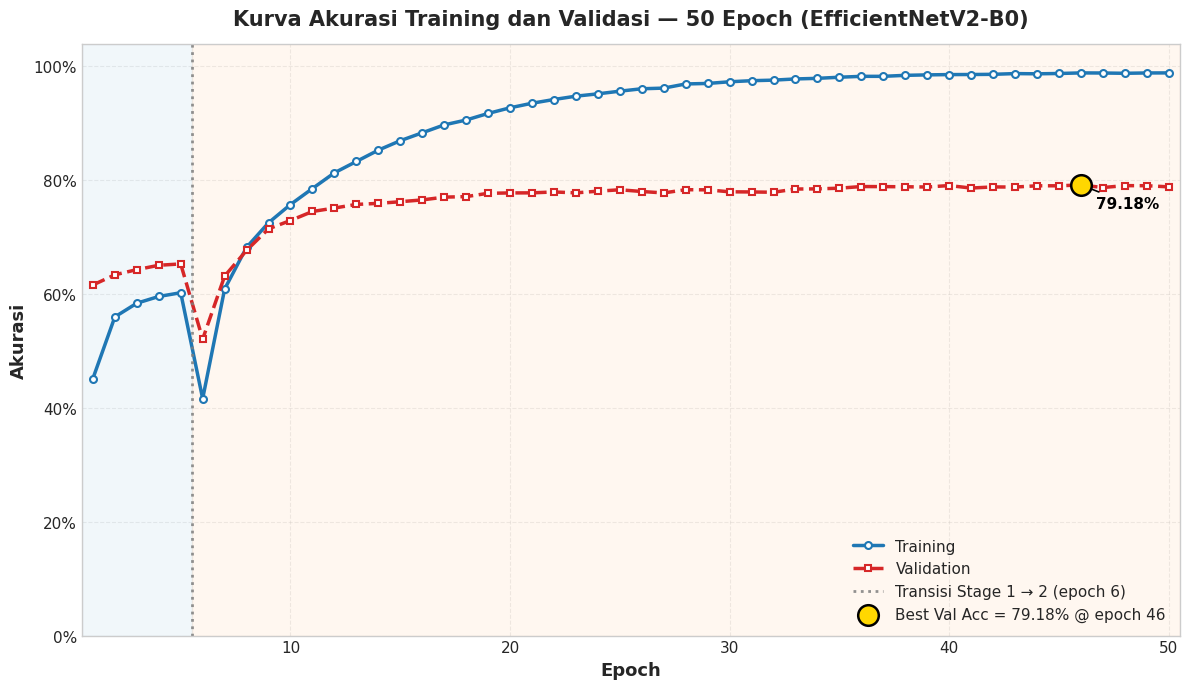

📊 Train Acc final  : 98.87%
📊 Val Acc final    : 78.85%
🏆 Best Val Acc     : 79.18% (epoch 46)
💾 Gambar disimpan  : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_1_accuracy.png


In [ ]:
# @title 7a. Grafik Kurva Akurasi Training dan Validasi (Gambar 4.1)
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
total_epochs = len(acc)
epochs_range = np.arange(1, total_epochs + 1)

# Best epoch
best_val_idx   = int(np.argmax(val_acc))
best_val_epoch = best_val_idx + 1
best_val_acc   = val_acc[best_val_idx]

fig, ax = plt.subplots(figsize=(12, 7))

# Garis utama
ax.plot(epochs_range, acc,     label='Training',   color='#1f77b4', linewidth=2.5,
        marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax.plot(epochs_range, val_acc, label='Validation', color='#d62728', linewidth=2.5,
        linestyle='--', marker='s', markersize=5, markerfacecolor='white', markeredgewidth=1.5)

# Garis transisi Stage 1 → Stage 2 (jika tersedia)
if 'STAGE1_EPOCHS' in globals() and STAGE1_EPOCHS < total_epochs:
    ax.axvline(STAGE1_EPOCHS + 0.5, color='#7f7f7f', linestyle=':', linewidth=2,
               alpha=0.85, label=f'Transisi Stage 1 → 2 (epoch {STAGE1_EPOCHS + 1})')
    ax.axvspan(0.5, STAGE1_EPOCHS + 0.5,           alpha=0.06, color='#1f77b4')
    ax.axvspan(STAGE1_EPOCHS + 0.5, total_epochs + 0.5, alpha=0.06, color='#ff7f0e')

# Marker best validation
ax.scatter([best_val_epoch], [best_val_acc], s=220, color='gold',
           edgecolor='black', linewidth=1.8, zorder=10,
           label=f'Best Val Acc = {best_val_acc*100:.2f}% @ epoch {best_val_epoch}')
ax.annotate(f'{best_val_acc*100:.2f}%',
            xy=(best_val_epoch, best_val_acc),
            xytext=(best_val_epoch + 0.7, best_val_acc - 0.04),
            fontsize=11, fontweight='bold', color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_title(f'Kurva Akurasi Training dan Validasi — {total_epochs} Epoch (EfficientNetV2-B0)',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Akurasi', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95, edgecolor='#333333')
ax.grid(True, alpha=0.35, linestyle='--')
ax.set_xlim(0.5, total_epochs + 0.5)
ax.set_ylim(0, max(1.0, max(max(acc), max(val_acc)) + 0.05))
ax.tick_params(axis='both', labelsize=11)

# Format y-axis sebagai persentase
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_1_accuracy.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"📊 Train Acc final  : {acc[-1]*100:.2f}%")
print(f"📊 Val Acc final    : {val_acc[-1]*100:.2f}%")
print(f"🏆 Best Val Acc     : {best_val_acc*100:.2f}% (epoch {best_val_epoch})")
print(f"💾 Gambar disimpan  : {os.path.join(MODELS_DIR, 'fig_4_1_accuracy.png')}")

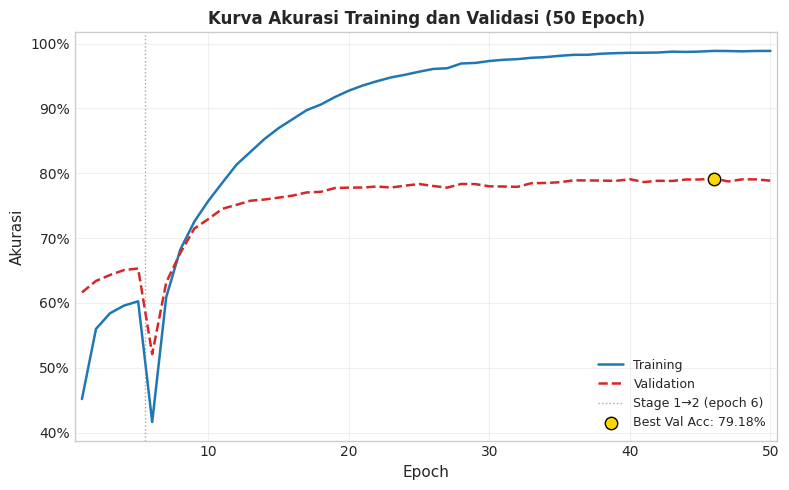

💾 Versi paper Sinta 5: /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_1_accuracy_lite.png


In [ ]:
# @title 7a-lite. Akurasi (Versi Minimalis untuk Paper Sinta 5)
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
total_epochs = len(acc)
epochs_range = np.arange(1, total_epochs + 1)

best_idx = int(np.argmax(val_acc))
best_val_acc = val_acc[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, acc,     label='Training',   color='#1f77b4', linewidth=1.8)
ax.plot(epochs_range, val_acc, label='Validation', color='#d62728',
        linestyle='--', linewidth=1.8)

# Stage transition: tipis, tanpa axvspan
if 'STAGE1_EPOCHS' in globals() and STAGE1_EPOCHS < total_epochs:
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':',
               linewidth=1.0, alpha=0.7,
               label=f'Stage 1→2 (epoch {STAGE1_EPOCHS + 1})')

# Best marker (kecil, simbolik)
ax.scatter([best_idx + 1], [best_val_acc], s=80, color='gold',
           edgecolor='black', linewidth=1.0, zorder=10,
           label=f'Best Val Acc: {best_val_acc*100:.2f}%')

ax.set_title(f'Kurva Akurasi Training dan Validasi ({total_epochs} Epoch)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Akurasi', fontsize=11)
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, total_epochs + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_1_accuracy_lite.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Versi paper Sinta 5: {os.path.join(MODELS_DIR, 'fig_4_1_accuracy_lite.png')}")

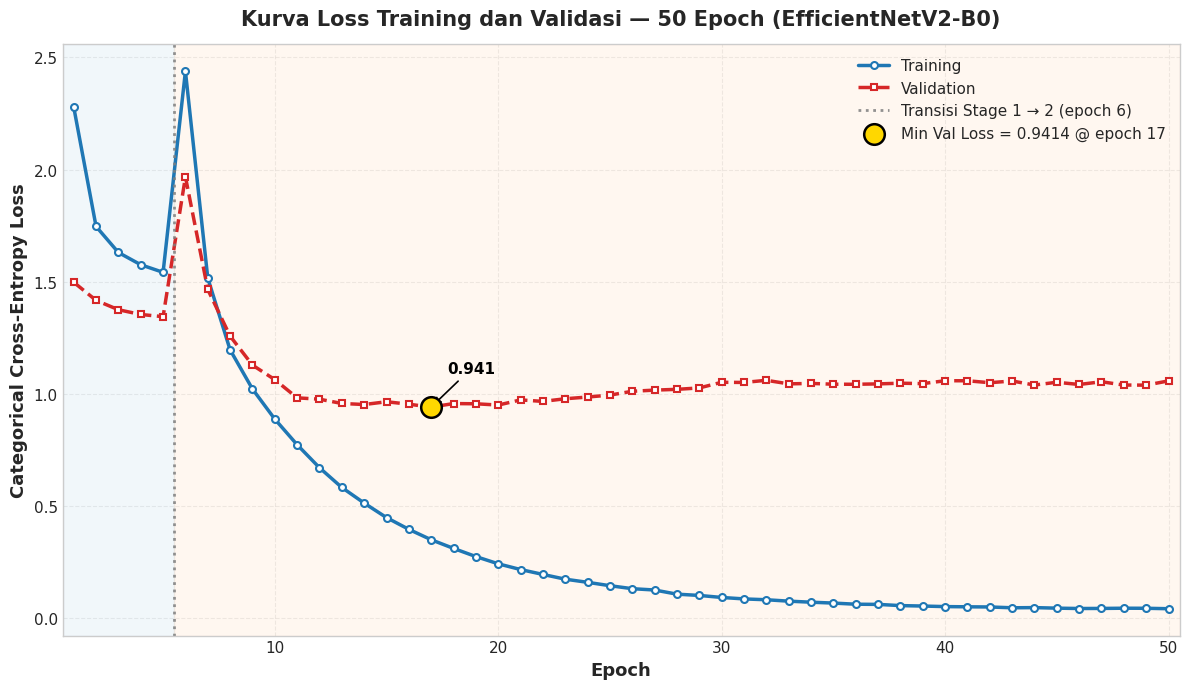

📊 Train Loss final : 0.0426
📊 Val Loss final   : 1.0582
🏆 Min Val Loss     : 0.9414 (epoch 17)
💾 Gambar disimpan  : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_2_loss.png


In [ ]:
# @title 7b. Grafik Kurva Loss Training dan Validasi (Gambar 4.2)
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

loss      = history.history['loss']
val_loss  = history.history['val_loss']
total_epochs = len(loss)
epochs_range = np.arange(1, total_epochs + 1)

best_val_loss_idx   = int(np.argmin(val_loss))
best_val_loss_epoch = best_val_loss_idx + 1
best_val_loss       = val_loss[best_val_loss_idx]

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(epochs_range, loss,     label='Training',   color='#1f77b4', linewidth=2.5,
        marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax.plot(epochs_range, val_loss, label='Validation', color='#d62728', linewidth=2.5,
        linestyle='--', marker='s', markersize=5, markerfacecolor='white', markeredgewidth=1.5)

if 'STAGE1_EPOCHS' in globals() and STAGE1_EPOCHS < total_epochs:
    ax.axvline(STAGE1_EPOCHS + 0.5, color='#7f7f7f', linestyle=':', linewidth=2,
               alpha=0.85, label=f'Transisi Stage 1 → 2 (epoch {STAGE1_EPOCHS + 1})')
    ax.axvspan(0.5, STAGE1_EPOCHS + 0.5,           alpha=0.06, color='#1f77b4')
    ax.axvspan(STAGE1_EPOCHS + 0.5, total_epochs + 0.5, alpha=0.06, color='#ff7f0e')

# Marker minimum val loss
ax.scatter([best_val_loss_epoch], [best_val_loss], s=220, color='gold',
           edgecolor='black', linewidth=1.8, zorder=10,
           label=f'Min Val Loss = {best_val_loss:.4f} @ epoch {best_val_loss_epoch}')
ax.annotate(f'{best_val_loss:.3f}',
            xy=(best_val_loss_epoch, best_val_loss),
            xytext=(best_val_loss_epoch + 0.7, best_val_loss + 0.15),
            fontsize=11, fontweight='bold', color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_title(f'Kurva Loss Training dan Validasi — {total_epochs} Epoch (EfficientNetV2-B0)',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Categorical Cross-Entropy Loss', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, edgecolor='#333333')
ax.grid(True, alpha=0.35, linestyle='--')
ax.set_xlim(0.5, total_epochs + 0.5)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_2_loss.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"📊 Train Loss final : {loss[-1]:.4f}")
print(f"📊 Val Loss final   : {val_loss[-1]:.4f}")
print(f"🏆 Min Val Loss     : {best_val_loss:.4f} (epoch {best_val_loss_epoch})")
print(f"💾 Gambar disimpan  : {os.path.join(MODELS_DIR, 'fig_4_2_loss.png')}")

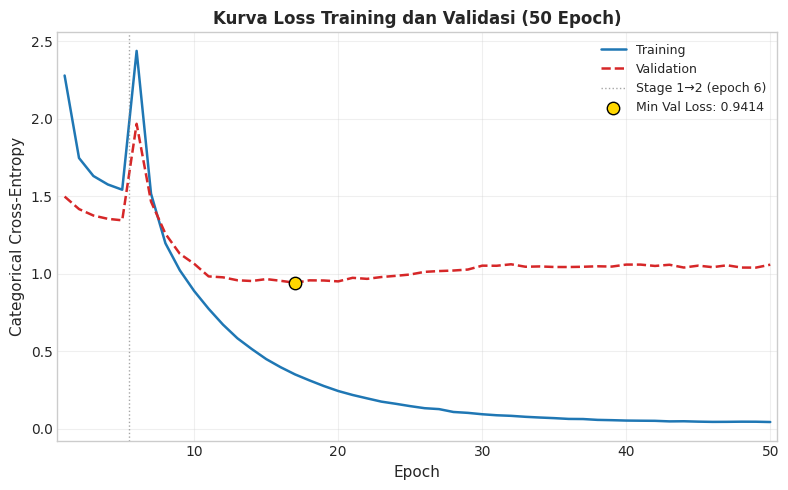

💾 Versi paper Sinta 5: /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_2_loss_lite.png


In [ ]:
# @title 7b-lite. Loss (Versi Minimalis untuk Paper Sinta 5)
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

loss     = history.history['loss']
val_loss = history.history['val_loss']
total_epochs = len(loss)
epochs_range = np.arange(1, total_epochs + 1)

best_loss_idx = int(np.argmin(val_loss))
best_val_loss = val_loss[best_loss_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, loss,     label='Training',   color='#1f77b4', linewidth=1.8)
ax.plot(epochs_range, val_loss, label='Validation', color='#d62728',
        linestyle='--', linewidth=1.8)

if 'STAGE1_EPOCHS' in globals() and STAGE1_EPOCHS < total_epochs:
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':',
               linewidth=1.0, alpha=0.7,
               label=f'Stage 1→2 (epoch {STAGE1_EPOCHS + 1})')

ax.scatter([best_loss_idx + 1], [best_val_loss], s=80, color='gold',
           edgecolor='black', linewidth=1.0, zorder=10,
           label=f'Min Val Loss: {best_val_loss:.4f}')

ax.set_title(f'Kurva Loss Training dan Validasi ({total_epochs} Epoch)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Categorical Cross-Entropy', fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, total_epochs + 0.5)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_2_loss_lite.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Versi paper Sinta 5: {os.path.join(MODELS_DIR, 'fig_4_2_loss_lite.png')}")

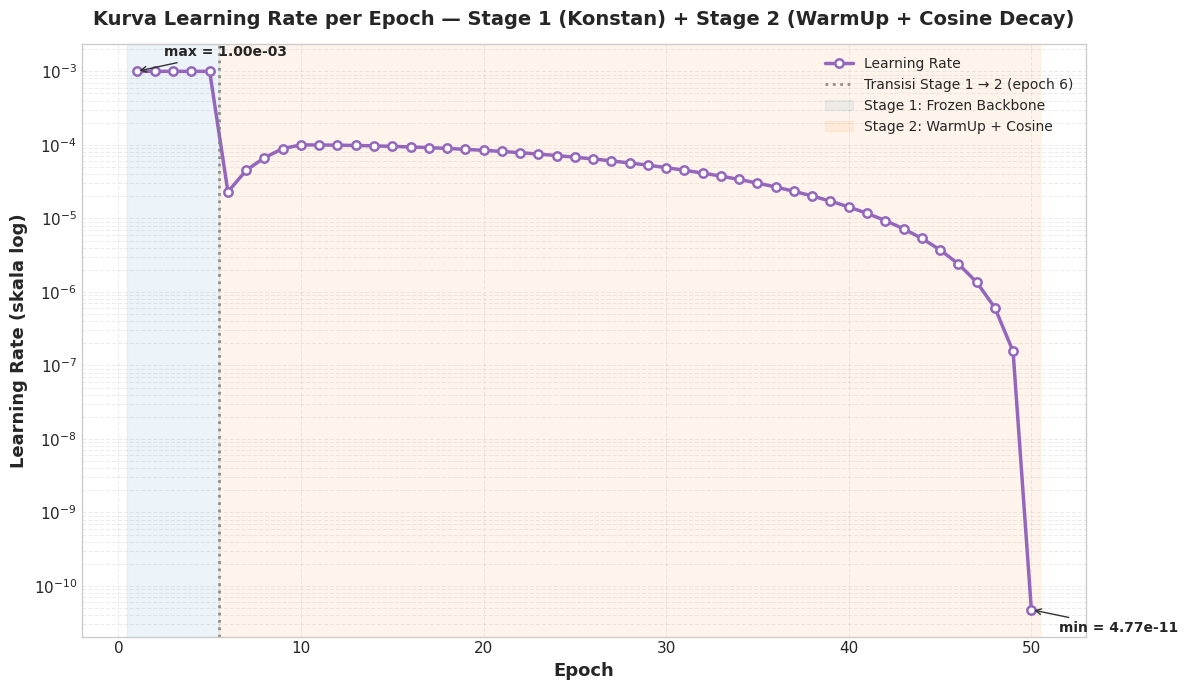

📊 Rentang LR tercatat : 4.77e-11 .. 1.00e-03
🎯 LR puncak           : 1.00e-03 (epoch 1)
🎯 LR terendah         : 4.77e-11 (epoch 50)
💾 Gambar disimpan     : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_3_learning_rate.png


In [ ]:
# @title 7c. Grafik Learning Rate Schedule per Epoch (Gambar 4.3)
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

log_path = os.path.join(MODELS_DIR, 'training_log.csv')
df_log = pd.read_csv(log_path)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(12, 7))

epochs_x = df_log['epoch'].values + 1   # 1-indexed untuk pembaca
lr_y     = df_log['lr'].values

ax.plot(epochs_x, lr_y, color='#9467bd', linewidth=2.5,
        marker='o', markersize=6, markerfacecolor='white', markeredgewidth=1.8,
        label='Learning Rate')

# Garis transisi Stage 1 → Stage 2
if 'STAGE1_EPOCHS' in globals():
    ax.axvline(STAGE1_EPOCHS + 0.5, color='#7f7f7f', linestyle=':', linewidth=2,
               alpha=0.85, label=f'Transisi Stage 1 → 2 (epoch {STAGE1_EPOCHS + 1})')
    ax.axvspan(0.5, STAGE1_EPOCHS + 0.5,                   alpha=0.08, color='#1f77b4',
               label='Stage 1: Frozen Backbone')
    ax.axvspan(STAGE1_EPOCHS + 0.5, len(epochs_x) + 0.5,   alpha=0.08, color='#ff7f0e',
               label='Stage 2: WarmUp + Cosine')

# Annotate min/max LR
lr_min, lr_max = lr_y.min(), lr_y.max()
ep_max = epochs_x[int(np.argmax(lr_y))]
ep_min = epochs_x[int(np.argmin(lr_y))]
ax.annotate(f'max = {lr_max:.2e}', xy=(ep_max, lr_max),
            xytext=(ep_max + 1.5, lr_max * 1.6),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.annotate(f'min = {lr_min:.2e}', xy=(ep_min, lr_min),
            xytext=(ep_min + 1.5, lr_min * 0.5),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))

ax.set_yscale('log')
ax.set_title('Kurva Learning Rate per Epoch — Stage 1 (Konstan) + Stage 2 (WarmUp + Cosine Decay)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Learning Rate (skala log)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#333333')
ax.grid(True, which='both', alpha=0.35, linestyle='--')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_3_learning_rate.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"📊 Rentang LR tercatat : {lr_min:.2e} .. {lr_max:.2e}")
print(f"🎯 LR puncak           : {lr_max:.2e} (epoch {ep_max})")
print(f"🎯 LR terendah         : {lr_min:.2e} (epoch {ep_min})")
print(f"💾 Gambar disimpan     : {os.path.join(MODELS_DIR, 'fig_4_3_learning_rate.png')}")

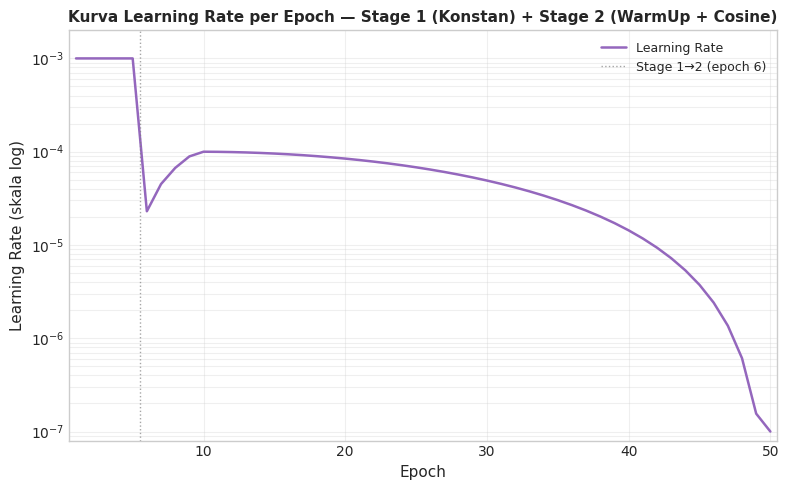

💾 Versi paper Sinta 5: /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_3_learning_rate_lite.png
📊 LR range actual: 4.77e-11 → 1.00e-03
   (nilai < 1e-07 di-clip untuk visualisasi)


In [ ]:
# @title 7c-lite. Learning Rate (Versi Minimalis untuk Paper Sinta 5 + Fix ylim)
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

log_path = os.path.join(MODELS_DIR, 'training_log.csv')
df_log = pd.read_csv(log_path)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

epochs_x = df_log['epoch'].values + 1
lr_y     = df_log['lr'].values

# === FIX: clip nilai LR yang terlalu kecil agar tidak distort plot ===
# Nilai LR < 1e-7 dianggap "praktis nol" dan menghilangkan empty space di bawah
LR_FLOOR = 1e-7
lr_y_display = np.clip(lr_y, LR_FLOOR, None)

# Range untuk display
lr_min_actual = lr_y[lr_y > 0].min() if any(lr_y > 0) else LR_FLOOR
lr_max_actual = lr_y.max()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_x, lr_y_display, color='#9467bd', linewidth=1.8, label='Learning Rate')

if 'STAGE1_EPOCHS' in globals():
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':',
               linewidth=1.0, alpha=0.7,
               label=f'Stage 1→2 (epoch {STAGE1_EPOCHS + 1})')

ax.set_yscale('log')
# === FIX KUNCI: clip ylim ke range realistis (no empty space) ===
ax.set_ylim(LR_FLOOR * 0.8, lr_max_actual * 2)

ax.set_title('Kurva Learning Rate per Epoch — Stage 1 (Konstan) + Stage 2 (WarmUp + Cosine)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Learning Rate (skala log)', fontsize=11)
ax.legend(loc='best', fontsize=9, framealpha=0.95)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0.5, len(epochs_x) + 0.5)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_3_learning_rate_lite.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Versi paper Sinta 5: {os.path.join(MODELS_DIR, 'fig_4_3_learning_rate_lite.png')}")
print(f"📊 LR range actual: {lr_min_actual:.2e} → {lr_max_actual:.2e}")
print(f"   (nilai < {LR_FLOOR:.0e} di-clip untuk visualisasi)")

In [ ]:
# @title 8. Evaluasi Model pada Test Set (Held-out: test.txt)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import numpy as np

print("=" * 64)
print("  EVALUASI FINAL PADA TEST SET (test.txt — HELD-OUT)")
print("=" * 64)

# --- A. Evaluasi Streaming (TIDAK memuat semua gambar ke RAM) ---
print("\n🔄 Menjalankan model.evaluate pada test_ds (streaming)...")
test_metrics = model.evaluate(test_ds, verbose=1, return_dict=True)
print(f"\n📊 METRIK tf.keras:")
print(f"   Test Loss           : {test_metrics['loss']:.4f}")
print(f"   Test Accuracy       : {test_metrics['accuracy']*100:.2f}%")
print(f"   Test Top-5 Accuracy : {test_metrics['top5_acc']*100:.2f}%")

# --- B. Prediksi Streaming untuk Analisis Detail ---
print("\n🔄 Menjalankan model.predict pada test_ds (streaming)...")
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)  # test_ds tidak di-shuffle → urutan sesuai test_labels

assert len(y_pred) == len(y_true), f"Mismatch panjang: pred={len(y_pred)}, true={len(y_true)}"

# --- C. Hitung Metrik Tambahan (Precision, Recall, F1, Top-5) ---
overall_acc   = accuracy_score(y_true, y_pred)
prec_macro    = precision_score(y_true, y_pred, average='macro',    zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_macro     = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
rec_weighted  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
f1_macro      = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
f1_weighted   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

# Top-5 Accuracy manual (cross-check dengan metrik Keras)
top5_preds   = np.argsort(-y_pred_probs, axis=1)[:, :5]
top5_correct = np.any(top5_preds == y_true.reshape(-1, 1), axis=1)
top5_acc     = np.mean(top5_correct)

# --- D. Tabel Ringkas Metrik (untuk skripsi Bab IV) ---
print("\n" + "=" * 64)
print("  📋 TABEL METRIK EVALUASI PADA TEST SET FOOD-101")
print("=" * 64)
print(f"  {'Metric':<32}{'Score':>12}")
print(f"  {'-'*32}{'-'*12}")
print(f"  {'Accuracy':<32}{overall_acc*100:>11.2f}%")
print(f"  {'Top-5 Accuracy':<32}{top5_acc*100:>11.2f}%")
print(f"  {'Precision (macro)':<32}{prec_macro*100:>11.2f}%")
print(f"  {'Precision (weighted)':<32}{prec_weighted*100:>11.2f}%")
print(f"  {'Recall (macro)':<32}{rec_macro*100:>11.2f}%")
print(f"  {'Recall (weighted)':<32}{rec_weighted*100:>11.2f}%")
print(f"  {'F1-Score (macro)':<32}{f1_macro*100:>11.2f}%")
print(f"  {'F1-Score (weighted)':<32}{f1_weighted*100:>11.2f}%")
print("=" * 64)

# --- E. Classification Report Per-Kelas (untuk Lampiran skripsi) ---
print("\n📑 Classification Report (per-kelas, 4 desimal):\n")
print(classification_report(
    y_true, y_pred,
    target_names=loaded_class_names,
    digits=4,
    zero_division=0
))


  EVALUASI FINAL PADA TEST SET (test.txt — HELD-OUT)

🔄 Menjalankan model.evaluate pada test_ds (streaming)...
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8453 - loss: 0.6863 - top5_acc: 0.9649

📊 METRIK tf.keras:
   Test Loss           : 0.6863
   Test Accuracy       : 84.53%
   Test Top-5 Accuracy : 96.49%

🔄 Menjalankan model.predict pada test_ds (streaming)...
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step

  📋 TABEL METRIK EVALUASI PADA TEST SET FOOD-101
  Metric                                 Score
  --------------------------------------------
  Accuracy                              84.53%
  Top-5 Accuracy                        96.49%
  Precision (macro)                     84.74%
  Precision (weighted)                  84.74%
  Recall (macro)                        84.53%
  Recall (weighted)                     84.53%
  F1-Score (macro)                      84.54%
  F1-Score (weighted)                   84.54%

📑 Classification Report (per-kelas, 4 desimal):

       

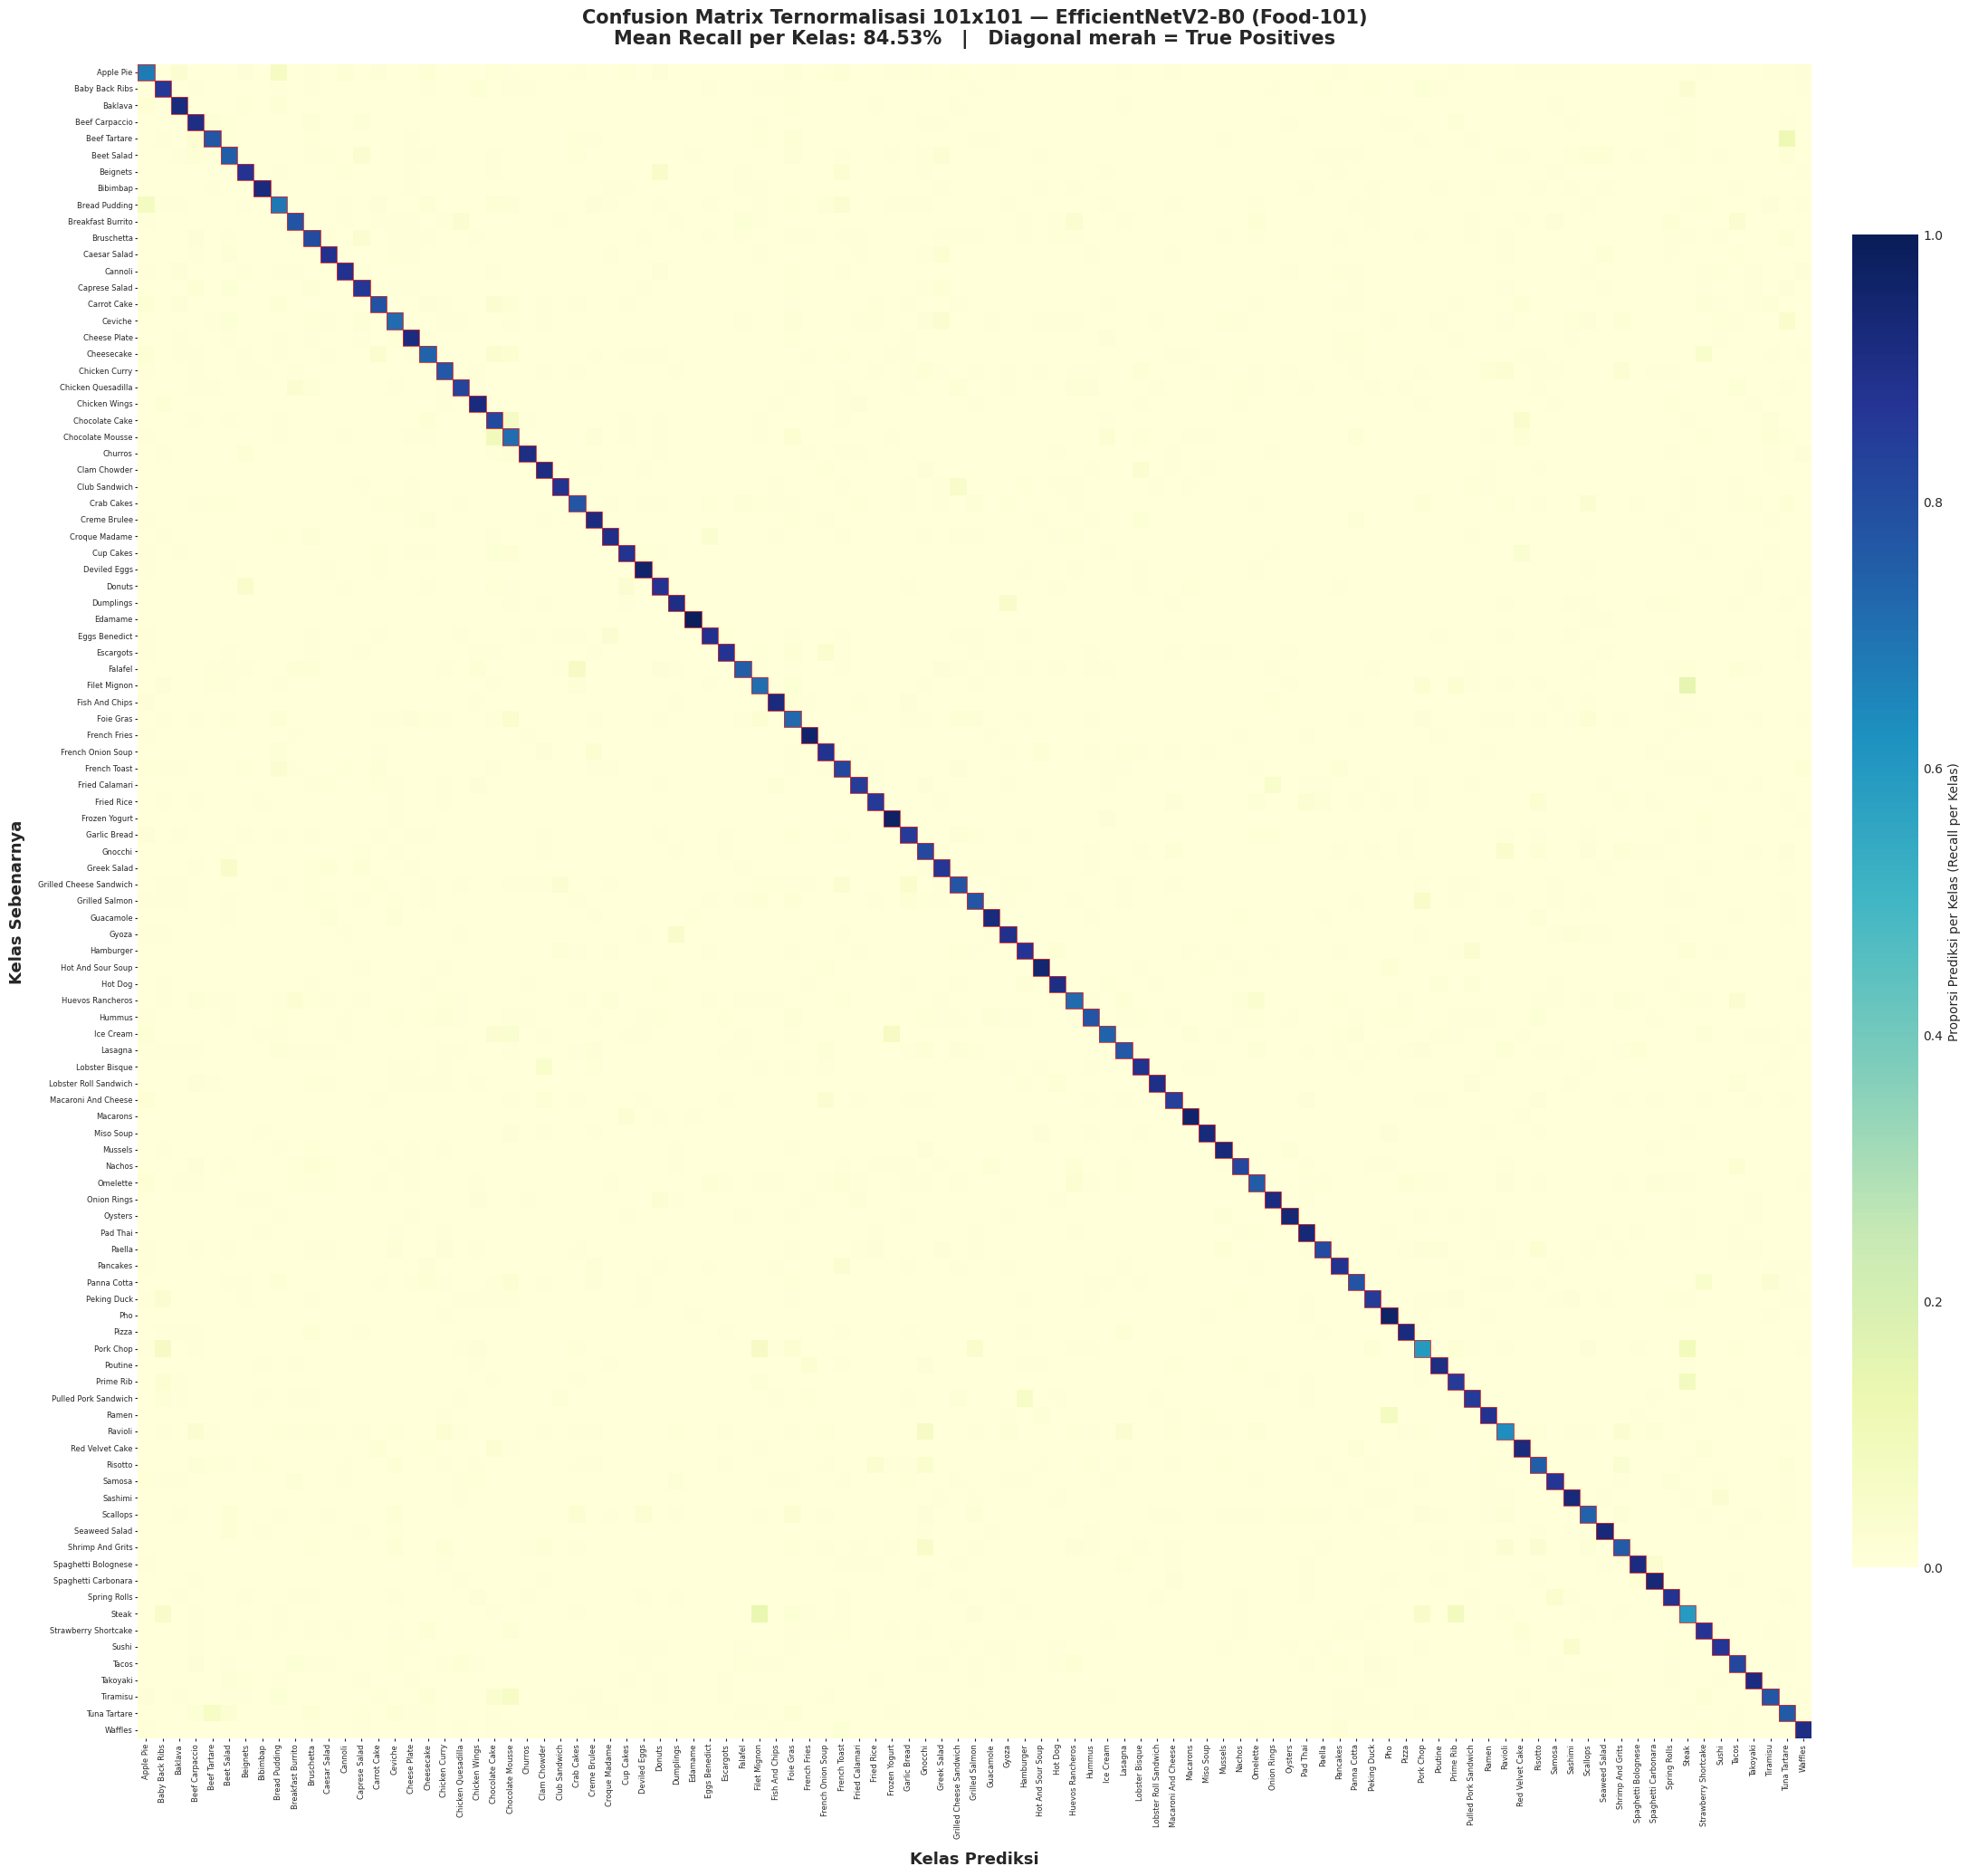

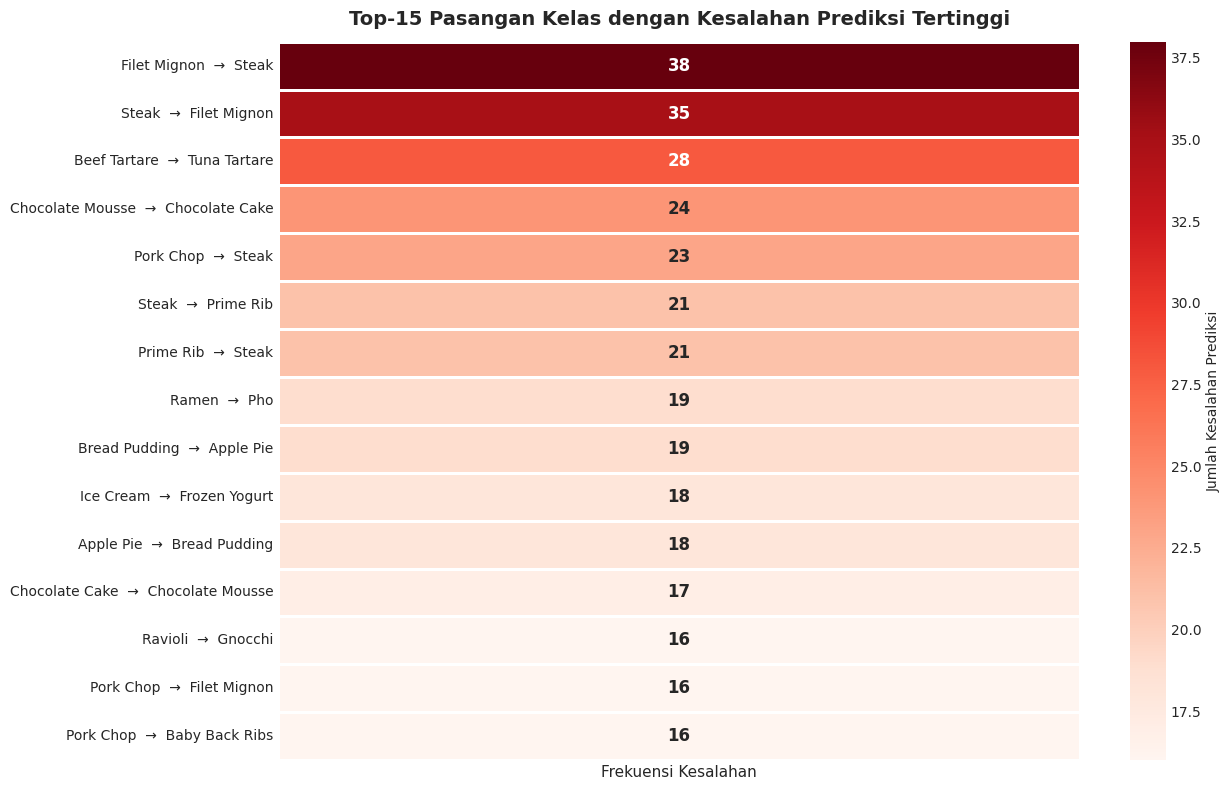


=== Tabel 4.3 — 15 Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===
No  Kelas Sebenarnya                Kelas Prediksi                   Frekuensi
------------------------------------------------------------------------------
1   Filet Mignon                    Steak                                   38
2   Steak                           Filet Mignon                            35
3   Beef Tartare                    Tuna Tartare                            28
4   Chocolate Mousse                Chocolate Cake                          24
5   Pork Chop                       Steak                                   23
6   Steak                           Prime Rib                               21
7   Prime Rib                       Steak                                   21
8   Ramen                           Pho                                     19
9   Bread Pudding                   Apple Pie                               19
10  Ice Cream                       Frozen Yogurt       

In [ ]:
# @title 8b. Heatmap Confusion Matrix 101x101 (Gambar 4.4)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix 101 x 101
cm = confusion_matrix(y_true, y_pred)

# Normalisasi per-baris (per kelas sebenarnya) — recall per kelas
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True).clip(min=1)

# Siapkan label nama kelas (untuk axis ticks)
display_labels = [c.replace('_', ' ').title() for c in loaded_class_names]

# === Plot 1: Full 101x101 heatmap DENGAN nama kelas ===
fig, ax = plt.subplots(figsize=(24, 22))

sns.heatmap(
    cm_normalized,
    cmap='YlGnBu',
    square=True,
    cbar_kws={'label': 'Proporsi Prediksi per Kelas (Recall per Kelas)',
              'shrink': 0.7, 'pad': 0.02},
    xticklabels=display_labels,
    yticklabels=display_labels,
    vmin=0, vmax=1,
    linewidths=0,
    ax=ax
)

# Highlight diagonal (true positives)
for i in range(cm_normalized.shape[0]):
    rect = plt.Rectangle((i, i), 1, 1, fill=False,
                         edgecolor='#d62728', linewidth=0.6)
    ax.add_patch(rect)

# Format ticklabels: kecil + rotated agar 101 nama tetap terbaca
ax.set_xticklabels(display_labels, rotation=90, ha='center', fontsize=6)
ax.set_yticklabels(display_labels, rotation=0,  va='center', fontsize=6)
ax.tick_params(axis='both', which='major', length=2, pad=2)

# Statistik global
overall_recall = float(np.diag(cm_normalized).mean())
ax.set_title(
    f'Confusion Matrix Ternormalisasi 101x101 — EfficientNetV2-B0 (Food-101)\n'
    f'Mean Recall per Kelas: {overall_recall*100:.2f}%   |   '
    f'Diagonal merah = True Positives',
    fontsize=15, fontweight='bold', pad=16
)
ax.set_xlabel('Kelas Prediksi', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Kelas Sebenarnya', fontsize=13, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_4_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# ====== Plot 2: Top-15 confusing pairs (heatmap kecil yang JELAS) ======
cm_offdiag = cm.copy().astype(int)
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i in range(cm_offdiag.shape[0]):
    for j in range(cm_offdiag.shape[1]):
        if cm_offdiag[i, j] > 0:
            pairs.append((int(cm_offdiag[i, j]), i, j))
pairs.sort(reverse=True)

top_n = 15
top_pairs = pairs[:top_n]
top_labels_y = []
top_data = np.zeros((top_n, 1), dtype=int)   # FIX: integer dtype agar fmt='d' jalan
for k, (cnt, ti, pj) in enumerate(top_pairs):
    true_name = loaded_class_names[ti].replace('_', ' ').title()
    pred_name = loaded_class_names[pj].replace('_', ' ').title()
    top_labels_y.append(f"{true_name}  →  {pred_name}")
    top_data[k, 0] = int(cnt)

fig2, ax2 = plt.subplots(figsize=(13, 8))
sns.heatmap(
    top_data,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar_kws={'label': 'Jumlah Kesalahan Prediksi'},
    yticklabels=top_labels_y,
    xticklabels=['Frekuensi Kesalahan'],
    linewidths=0.8, linecolor='white',
    ax=ax2,
    annot_kws={'fontsize': 12, 'fontweight': 'bold'}
)
ax2.set_title(f'Top-{top_n} Pasangan Kelas dengan Kesalahan Prediksi Tertinggi',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_yticklabels(top_labels_y, rotation=0, fontsize=10)
ax2.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_4b_top_confusing_pairs.png'), dpi=200, bbox_inches='tight')
plt.show()

# Print Tabel 4.3 ke stdout (untuk skripsi)
print(f"\n=== Tabel 4.3 — {top_n} Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===")
print(f"{'No':<4}{'Kelas Sebenarnya':<32}{'Kelas Prediksi':<32}{'Frekuensi':>10}")
print('-' * 78)
for k, (cnt, ti, pj) in enumerate(top_pairs, 1):
    tn = loaded_class_names[ti].replace('_', ' ').title()
    pn = loaded_class_names[pj].replace('_', ' ').title()
    print(f"{k:<4}{tn:<32}{pn:<32}{cnt:>10}")

print(f"\n💾 Gambar disimpan:")
print(f"   {os.path.join(MODELS_DIR, 'fig_4_4_confusion_matrix.png')}")
print(f"   {os.path.join(MODELS_DIR, 'fig_4_4b_top_confusing_pairs.png')}")

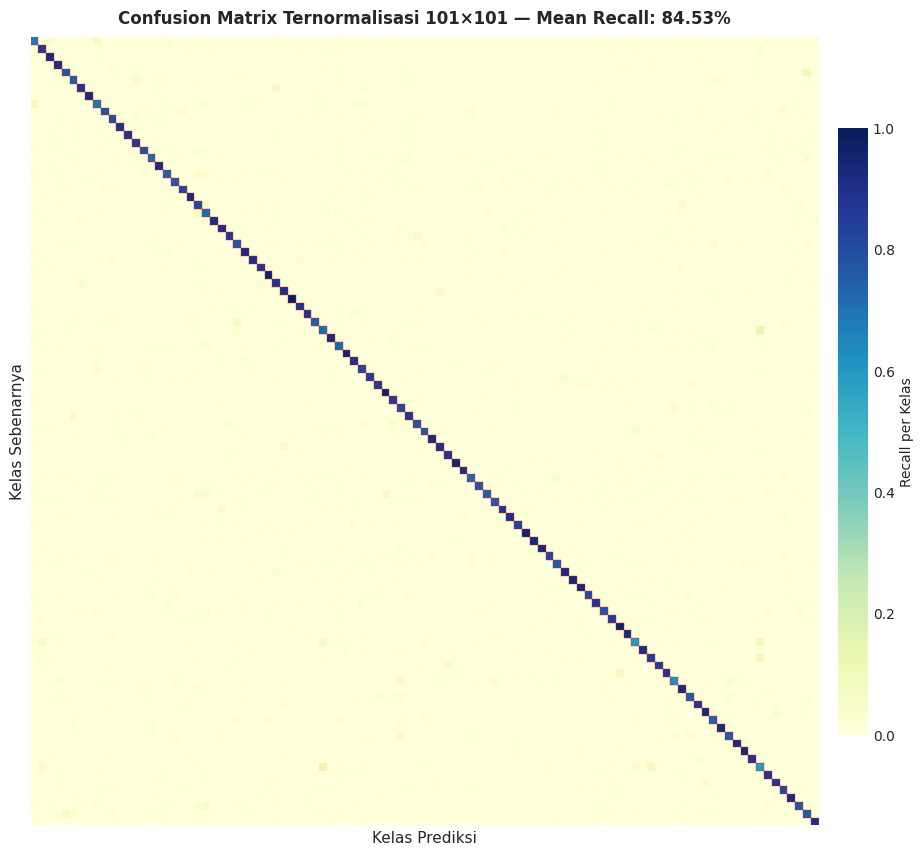


=== Top-10 Confusing Pairs (Tabel untuk Paper Sinta 5) ===
No  Kelas Sebenarnya            Kelas Prediksi                Freq
------------------------------------------------------------------
1   Filet Mignon                Steak                           38
2   Steak                       Filet Mignon                    35
3   Beef Tartare                Tuna Tartare                    28
4   Chocolate Mousse            Chocolate Cake                  24
5   Pork Chop                   Steak                           23
6   Steak                       Prime Rib                       21
7   Prime Rib                   Steak                           21
8   Ramen                       Pho                             19
9   Bread Pudding               Apple Pie                       19
10  Ice Cream                   Frozen Yogurt                   18

💾 Versi paper Sinta 5: /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_4_confusion_matrix_lite.png


In [ ]:
# @title 8b-lite. Heatmap Confusion Matrix (Versi Minimalis untuk Paper Sinta 5)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix 101 x 101
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True).clip(min=1)

# === Versi LITE: tanpa label kelas (101 nama terlalu kecil di paper) ===
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(
    cm_normalized,
    cmap='YlGnBu',
    square=True,
    cbar_kws={'label': 'Recall per Kelas', 'shrink': 0.7, 'pad': 0.02},
    xticklabels=False,
    yticklabels=False,
    vmin=0, vmax=1,
    linewidths=0,
    ax=ax
)

# Highlight diagonal (true positives) — tipis
for i in range(cm_normalized.shape[0]):
    rect = plt.Rectangle((i, i), 1, 1, fill=False,
                         edgecolor='#d62728', linewidth=0.3)
    ax.add_patch(rect)

overall_recall = float(np.diag(cm_normalized).mean())
ax.set_title(
    f'Confusion Matrix Ternormalisasi 101×101 — Mean Recall: {overall_recall*100:.2f}%',
    fontsize=12, fontweight='bold', pad=10
)
ax.set_xlabel('Kelas Prediksi', fontsize=11)
ax.set_ylabel('Kelas Sebenarnya', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_4_confusion_matrix_lite.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# === Tabel Top-10 confusing pairs (versi compact untuk paper) ===
cm_offdiag = cm.copy().astype(int)
np.fill_diagonal(cm_offdiag, 0)
pairs = []
for i in range(cm_offdiag.shape[0]):
    for j in range(cm_offdiag.shape[1]):
        if cm_offdiag[i, j] > 0:
            pairs.append((int(cm_offdiag[i, j]), i, j))
pairs.sort(reverse=True)

print(f"\n=== Top-10 Confusing Pairs (Tabel untuk Paper Sinta 5) ===")
print(f"{'No':<4}{'Kelas Sebenarnya':<28}{'Kelas Prediksi':<28}{'Freq':>6}")
print('-' * 66)
for k, (cnt, ti, pj) in enumerate(pairs[:10], 1):
    tn = loaded_class_names[ti].replace('_', ' ').title()
    pn = loaded_class_names[pj].replace('_', ' ').title()
    print(f"{k:<4}{tn:<28}{pn:<28}{cnt:>6}")

print(f"\n💾 Versi paper Sinta 5: {os.path.join(MODELS_DIR, 'fig_4_4_confusion_matrix_lite.png')}")

In [ ]:
# @title 9. Akurasi Per Kelas Makanan (Tabel Lengkap)
import pandas as pd
import numpy as np

print("=" * 60)
print("  AKURASI PER KELAS MAKANAN (101 KELAS)")
print("=" * 60)

# --- A. Hitung Akurasi Tiap Kelas ---
num_classes = len(loaded_class_names)
per_class_correct = np.zeros(num_classes)
per_class_total = np.zeros(num_classes)

for i in range(len(y_true)):
    true_label = y_true[i]
    per_class_total[true_label] += 1
    if y_pred[i] == true_label:
        per_class_correct[true_label] += 1

per_class_accuracy = per_class_correct / per_class_total

# --- B. Buat DataFrame Lengkap ---
df_accuracy = pd.DataFrame({
    'No': range(1, num_classes + 1),
    'Kelas Makanan': [name.replace('_', ' ').title() for name in loaded_class_names],
    'Label Asli': loaded_class_names,
    'Jumlah Sampel': per_class_total.astype(int),
    'Prediksi Benar': per_class_correct.astype(int),
    'Prediksi Salah': (per_class_total - per_class_correct).astype(int),
    'Akurasi (%)': np.round(per_class_accuracy * 100, 2)
})
df_accuracy = df_accuracy.set_index('No')

# --- C. Urutkan berdasarkan Akurasi (Tertinggi ke Terendah) ---
df_sorted = df_accuracy.sort_values(by='Akurasi (%)', ascending=False).reset_index(drop=True)
df_sorted.index = range(1, len(df_sorted) + 1)
df_sorted.index.name = 'Rank'

# --- D. Tampilkan Tabel Lengkap ---
pd.set_option('display.max_rows', 110)
print("\n📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):\n")
display(df_sorted[['Kelas Makanan', 'Jumlah Sampel', 'Prediksi Benar', 'Prediksi Salah', 'Akurasi (%)']])

# --- E. Statistik Ringkasan ---
print("\n" + "=" * 60)
print("  RINGKASAN STATISTIK AKURASI PER KELAS")
print("=" * 60)
print(f"  Rata-rata Akurasi   : {per_class_accuracy.mean()*100:.2f}%")
print(f"  Median Akurasi      : {np.median(per_class_accuracy)*100:.2f}%")
print(f"  Std. Deviasi        : {per_class_accuracy.std()*100:.2f}%")
print(f"  Akurasi Tertinggi   : {per_class_accuracy.max()*100:.2f}% ({loaded_class_names[np.argmax(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Akurasi Terendah    : {per_class_accuracy.min()*100:.2f}% ({loaded_class_names[np.argmin(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Kelas >= 90%        : {np.sum(per_class_accuracy >= 0.90)} kelas")
print(f"  Kelas >= 80%        : {np.sum(per_class_accuracy >= 0.80)} kelas")
print(f"  Kelas <  60%        : {np.sum(per_class_accuracy <  0.60)} kelas")
print("=" * 60)

  AKURASI PER KELAS MAKANAN (101 KELAS)

📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):



,Kelas Makanan,Jumlah Sampel,Prediksi Benar,Prediksi Salah,Akurasi (%)
Rank,,,,,
1,Edamame,250,248,2,99.2
2,Frozen Yogurt,250,243,7,97.2
3,Pho,250,242,8,96.8
4,Deviled Eggs,250,240,10,96.0
5,Macarons,250,240,10,96.0
6,French Fries,250,240,10,96.0
7,Hot And Sour Soup,250,238,12,95.2
8,Oysters,250,235,15,94.0
9,Spaghetti Carbonara,250,234,16,93.6



  RINGKASAN STATISTIK AKURASI PER KELAS
  Rata-rata Akurasi   : 84.53%
  Median Akurasi      : 87.20%
  Std. Deviasi        : 8.53%
  Akurasi Tertinggi   : 99.20% (Edamame)
  Akurasi Terendah    : 59.20% (Steak)
  Kelas >= 90%        : 35 kelas
  Kelas >= 80%        : 71 kelas
  Kelas <  60%        : 2 kelas


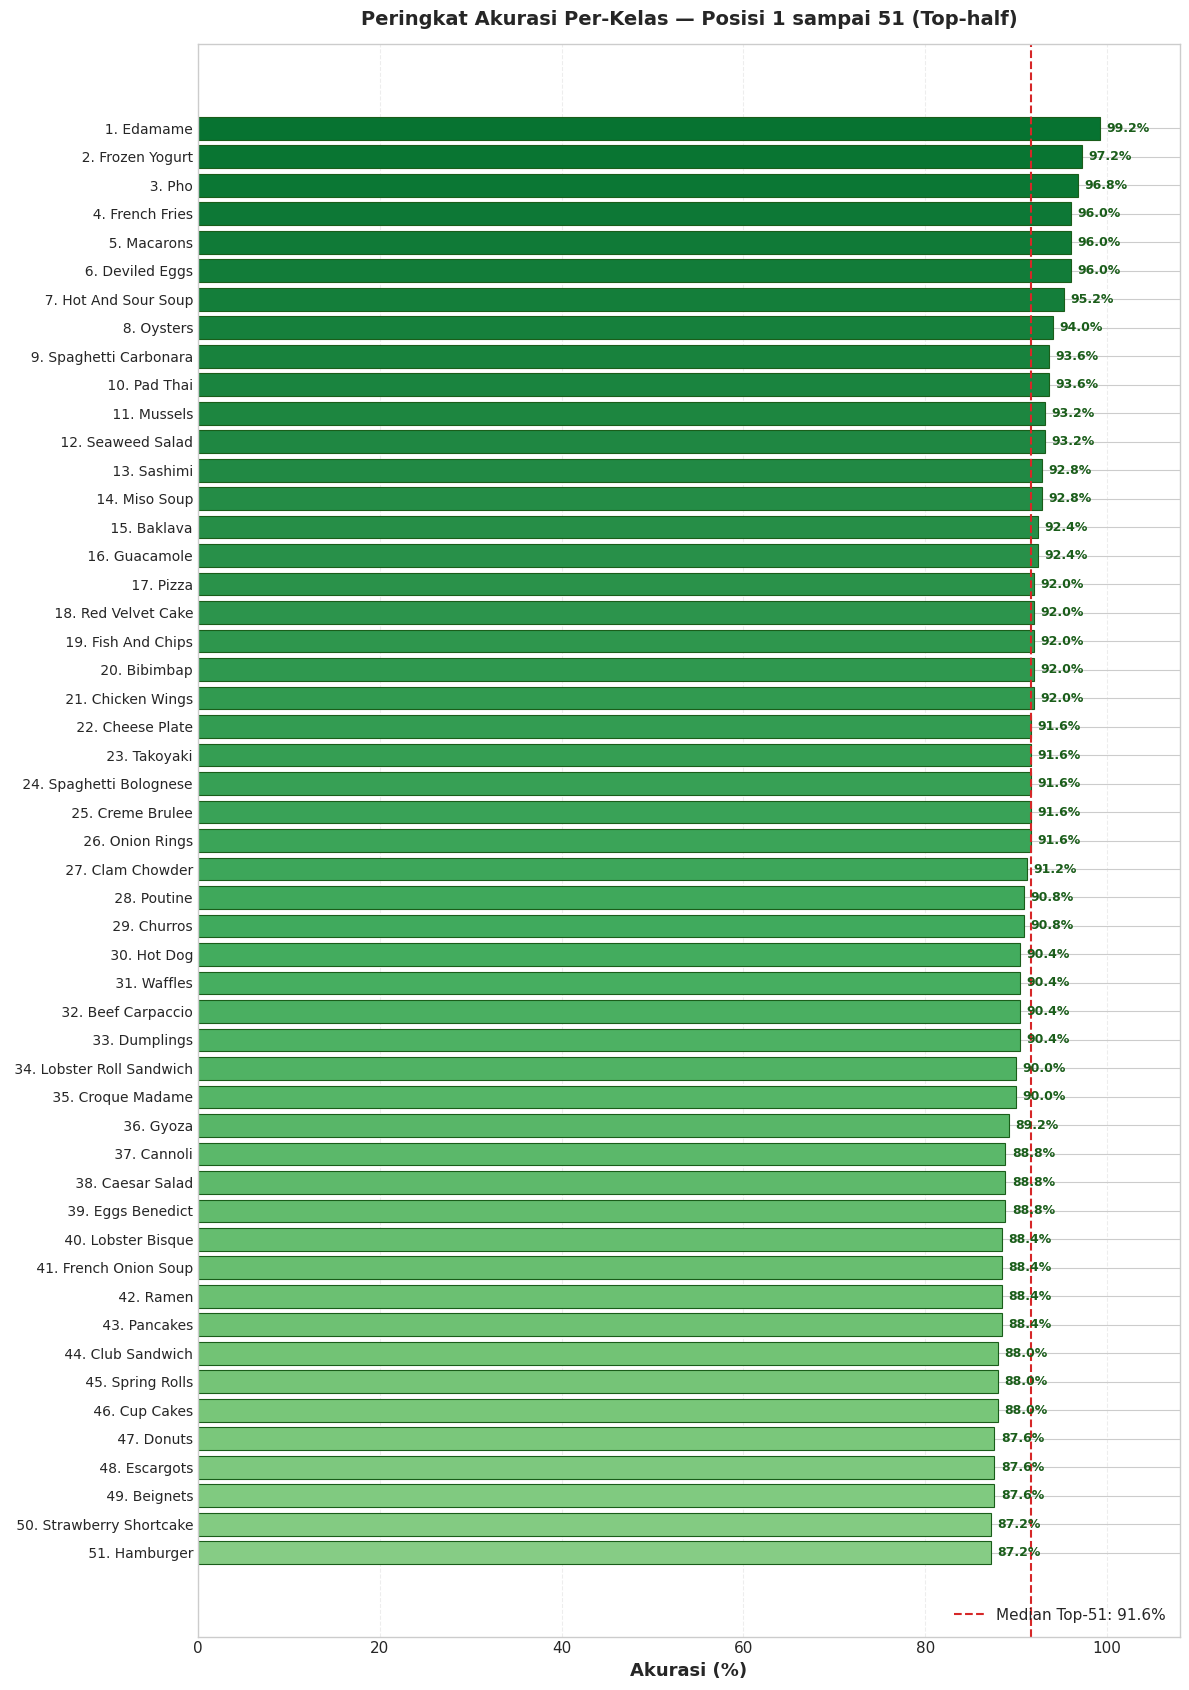

💾 Gambar disimpan : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_5a_rank_1_51.png


In [ ]:
# @title 10a. Visualisasi Peringkat Akurasi Kelas 1 - 51 (Top-half)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm as mpl_cm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]
all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc   = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

# Color gradient hijau berdasarkan ranking
colors_top = mpl_cm.Greens(np.linspace(0.85, 0.45, 51))

fig, ax = plt.subplots(figsize=(12, 17))
y_positions = np.arange(51)
bars = ax.barh(y_positions, all_acc[:51], color=colors_top,
               edgecolor='#1a5d1a', linewidth=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels([f'{i+1:>3}. {n}' for i, n in enumerate(all_names[:51])], fontsize=10)
ax.set_xlabel('Akurasi (%)', fontsize=13, fontweight='bold')
ax.set_title('Peringkat Akurasi Per-Kelas — Posisi 1 sampai 51 (Top-half)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlim(0, 108)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.35, linestyle='--')
ax.tick_params(axis='x', labelsize=11)

for bar, val in zip(bars, all_acc[:51]):
    ax.text(bar.get_width() + 0.7, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color='#1a5d1a')

# Median line
median_acc = float(np.median(all_acc[:51]))
ax.axvline(median_acc, color='#d62728', linestyle='--', linewidth=1.5,
           label=f'Median Top-51: {median_acc:.1f}%')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_5a_rank_1_51.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"💾 Gambar disimpan : {os.path.join(MODELS_DIR, 'fig_4_5a_rank_1_51.png')}")

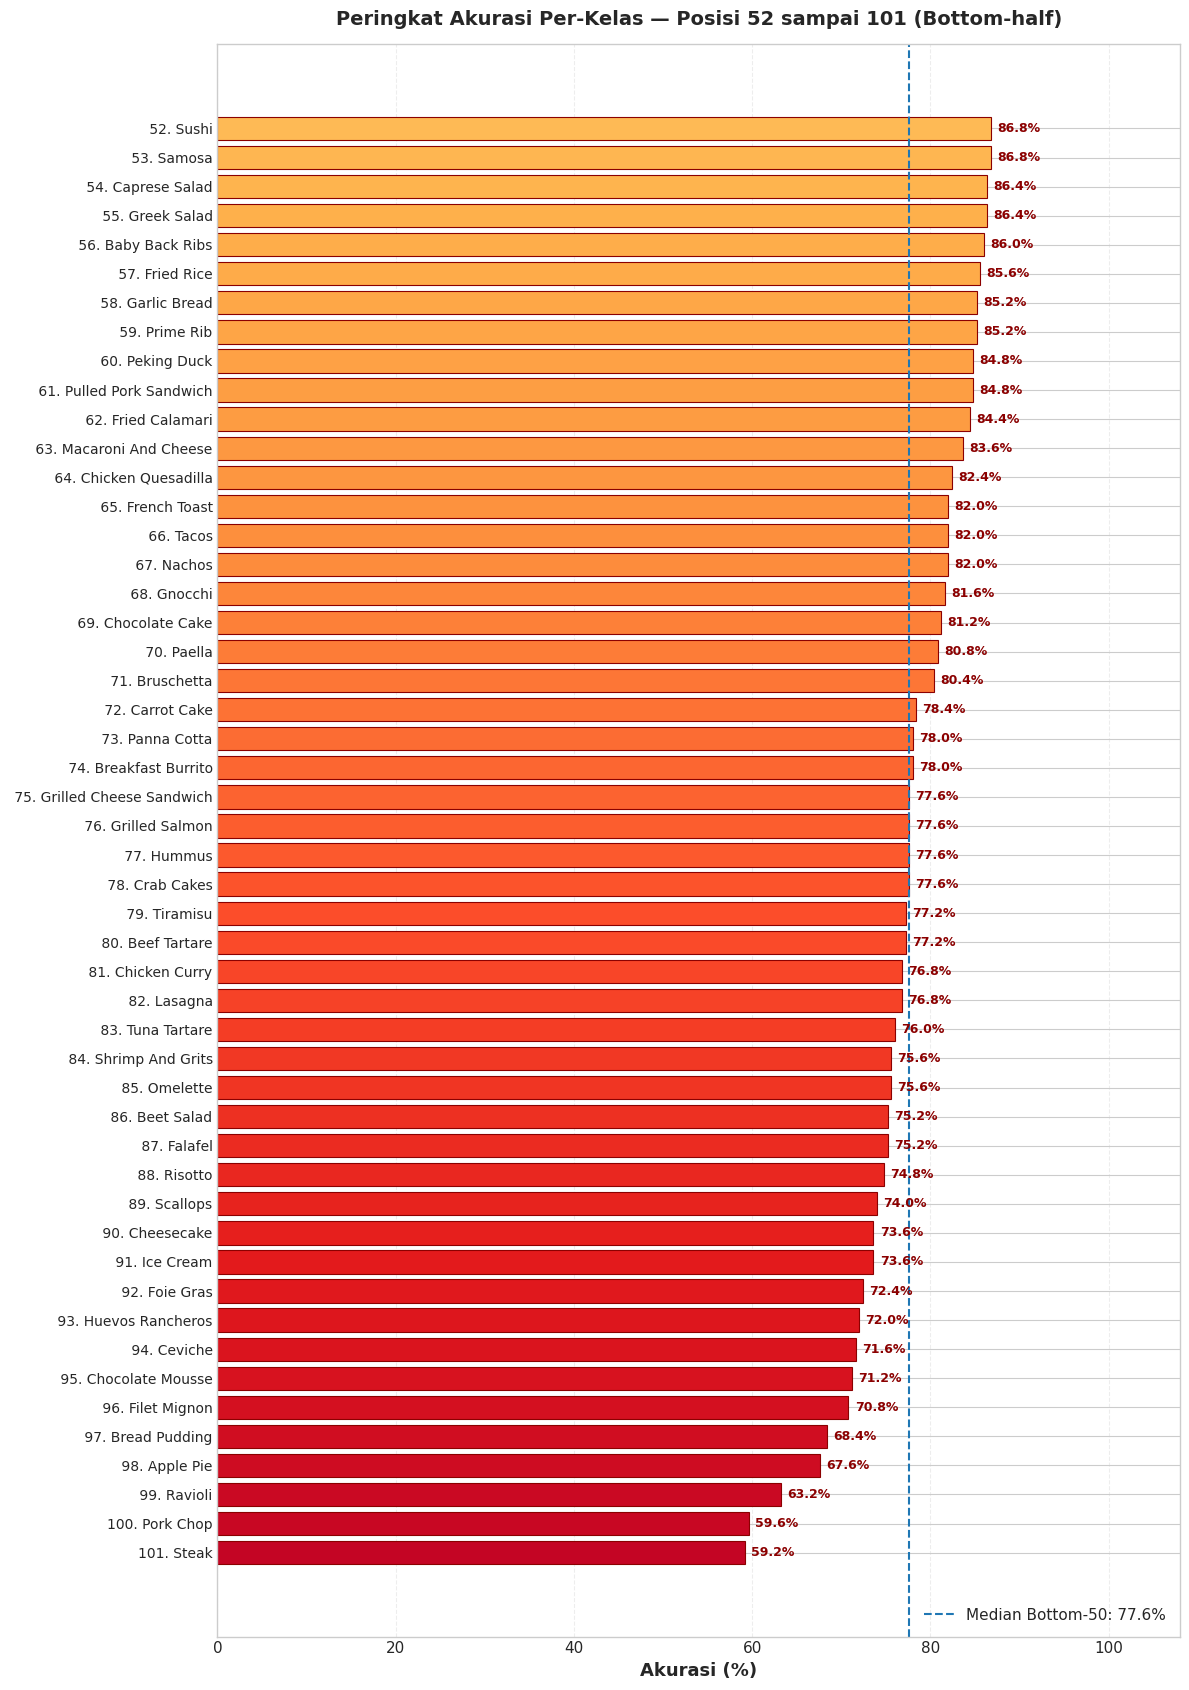

💾 Gambar disimpan : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_5b_rank_52_101.png


In [ ]:
# @title 10b. Visualisasi Peringkat Akurasi Kelas 52 - 101 (Bottom-half)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm as mpl_cm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]
all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc   = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

sisa_kelas = len(all_acc) - 51
if sisa_kelas > 0:
    # Color gradient: kuning → orange → merah (yang terendah)
    colors_bottom = mpl_cm.YlOrRd(np.linspace(0.35, 0.85, sisa_kelas))

    fig, ax = plt.subplots(figsize=(12, 17))
    y_positions = np.arange(sisa_kelas)
    bars = ax.barh(y_positions, all_acc[51:], color=colors_bottom,
                   edgecolor='#8b0000', linewidth=0.8)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([f'{i+52:>3}. {n}' for i, n in enumerate(all_names[51:])], fontsize=10)
    ax.set_xlabel('Akurasi (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'Peringkat Akurasi Per-Kelas — Posisi 52 sampai {len(all_acc)} (Bottom-half)',
                 fontsize=14, fontweight='bold', pad=14)
    ax.set_xlim(0, 108)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.35, linestyle='--')
    ax.tick_params(axis='x', labelsize=11)

    for bar, val in zip(bars, all_acc[51:]):
        ax.text(bar.get_width() + 0.7, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color='#8b0000')

    median_acc = float(np.median(all_acc[51:]))
    ax.axvline(median_acc, color='#1f77b4', linestyle='--', linewidth=1.5,
               label=f'Median Bottom-{sisa_kelas}: {median_acc:.1f}%')
    ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, 'fig_4_5b_rank_52_101.png'), dpi=200, bbox_inches='tight')
    plt.show()

    print(f"💾 Gambar disimpan : {os.path.join(MODELS_DIR, 'fig_4_5b_rank_52_101.png')}")

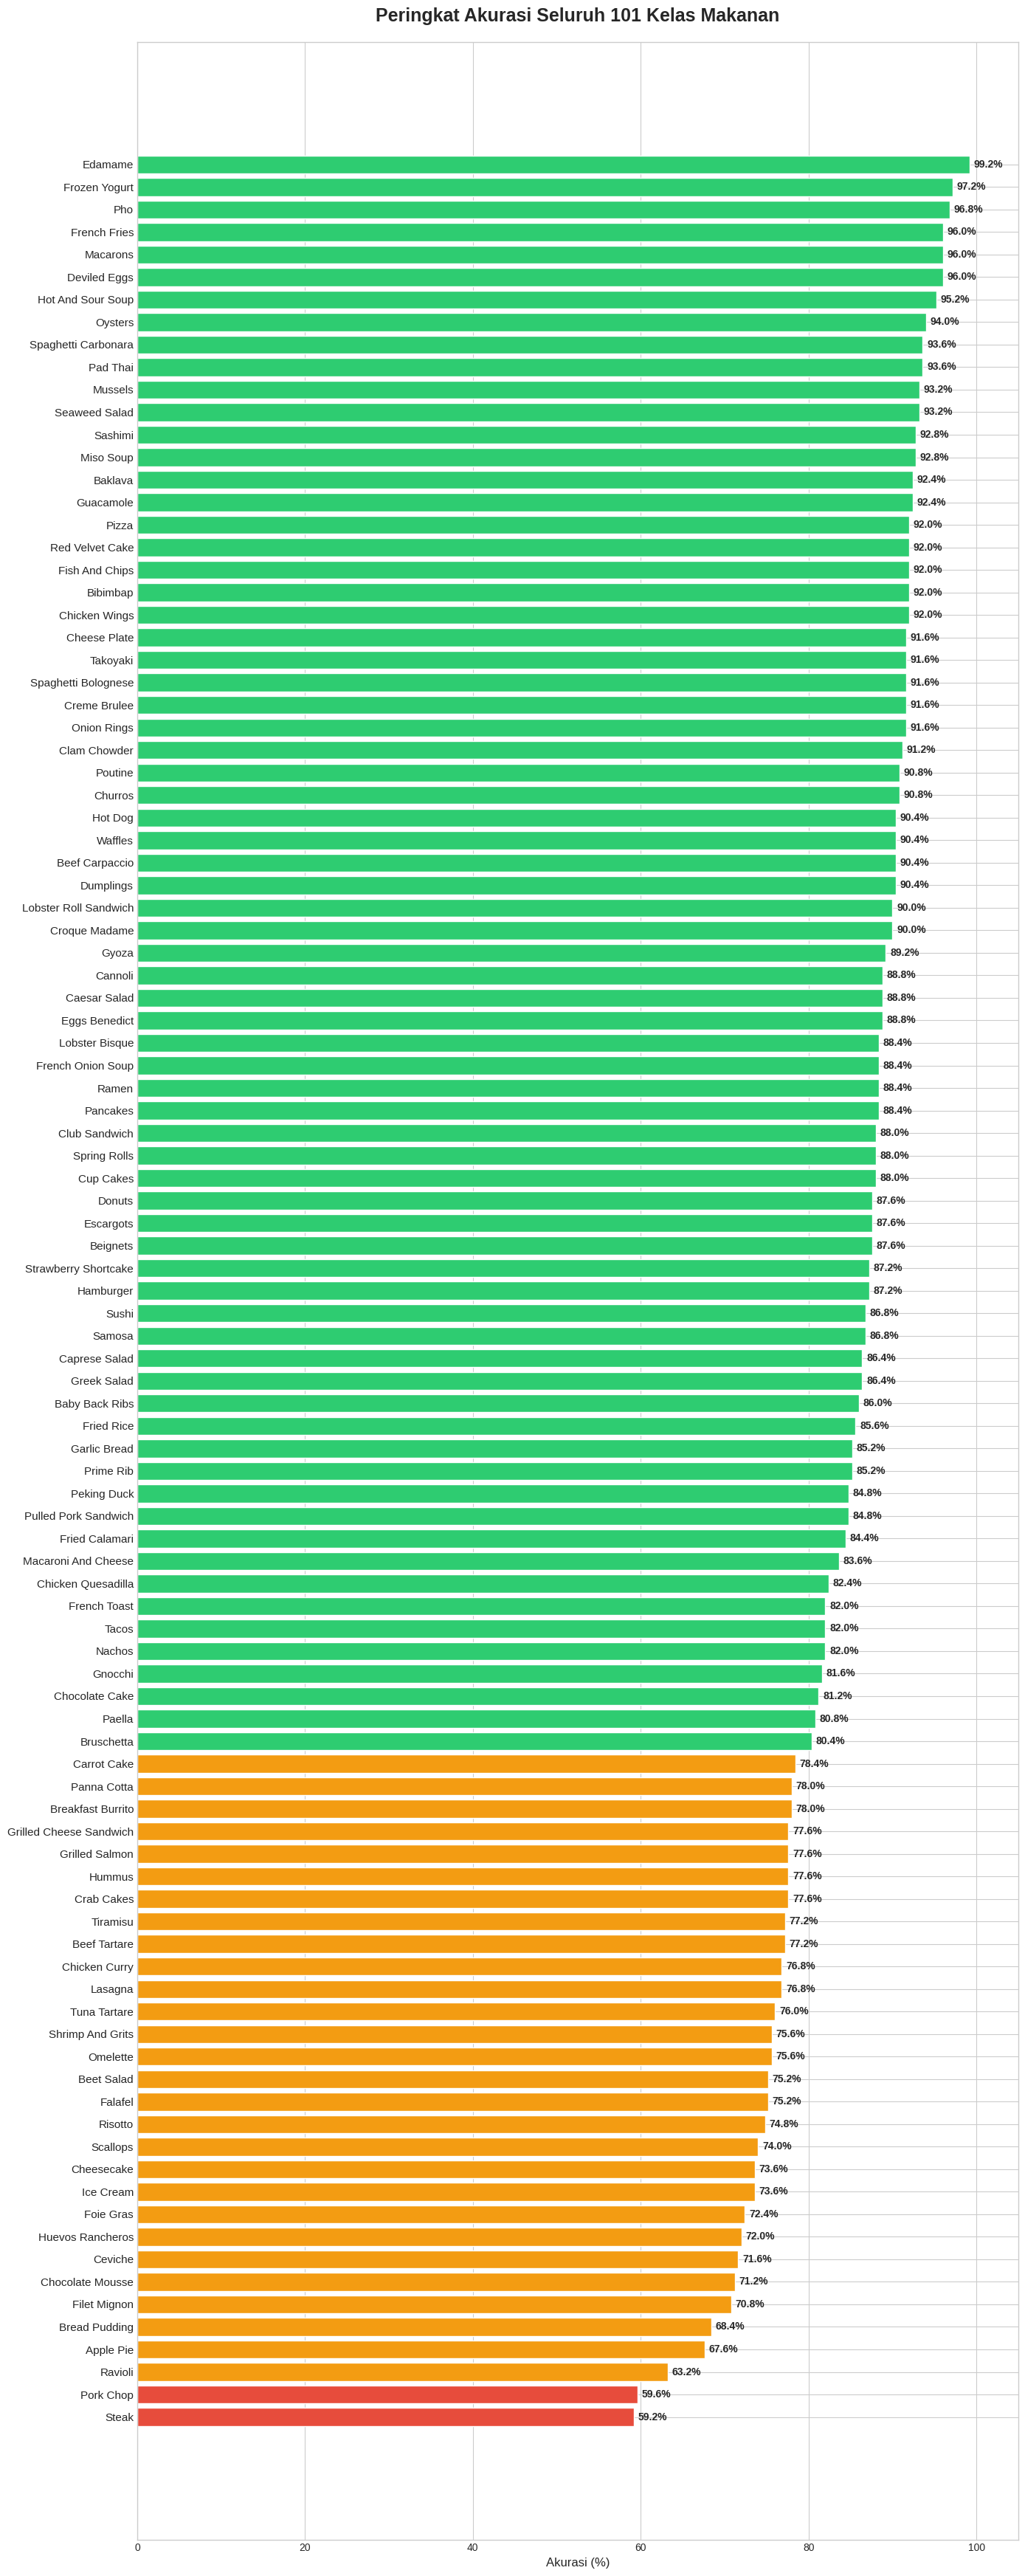

In [ ]:
# @title 11. Peringkat Akurasi Seluruh 101 Kelas
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]
total_classes = len(all_acc)

# Buat figure dengan 1 kolom dan tinggi yang sangat panjang (misal: lebar 14, tinggi 35)
fig, ax = plt.subplots(figsize=(14, 35))

# Tentukan warna (Hijau >= 80%, Oranye 60-79%, Merah < 60%)
colors = ['#2ecc71' if a >= 80 else '#f39c12' if a >= 60 else '#e74c3c' for a in all_acc]

# Buat bar chart horizontal
bars = ax.barh(range(total_classes), all_acc, color=colors, edgecolor='white')

# Set label sumbu Y dengan nama-nama kelas makanan
ax.set_yticks(range(total_classes))
ax.set_yticklabels(all_names, fontsize=11)
ax.set_xlabel('Akurasi (%)', fontsize=12)
ax.set_title(f'Peringkat Akurasi Seluruh {total_classes} Kelas Makanan', fontsize=18, fontweight='bold', pad=20)
ax.set_xlim(0, 105)

# Balik sumbu Y agar peringkat 1 berada di paling atas
ax.invert_yaxis()

# Tambahkan label teks persentase di ujung kanan setiap bar
for bar, val in zip(bars, all_acc):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

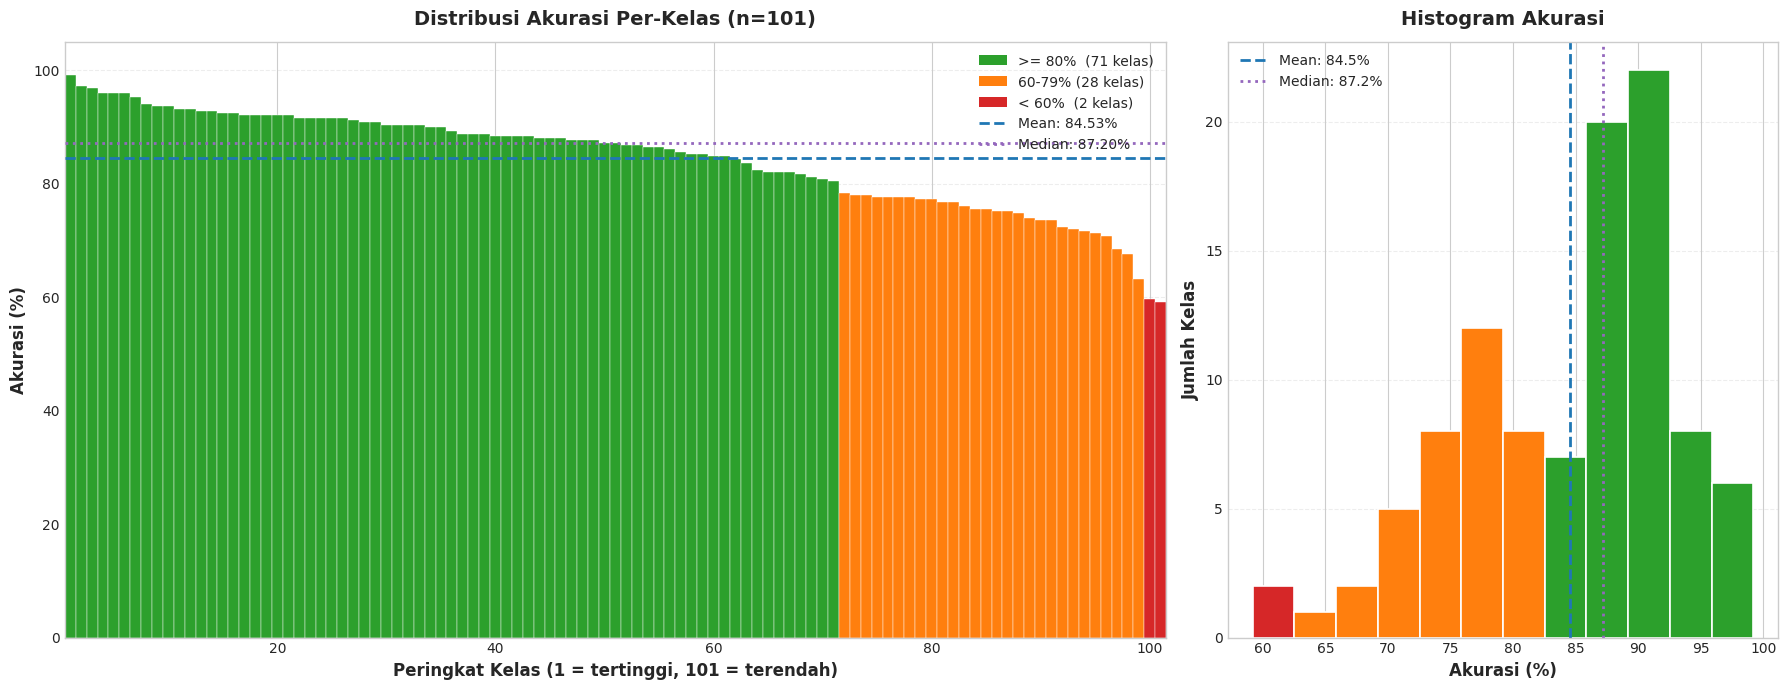


📊 STATISTIK DISTRIBUSI AKURASI PER-KELAS:
   • Mean   : 84.53%
   • Median : 87.20%
   • Std    : 8.53%
   • P25    : 77.60%   (kuartil bawah)
   • P75    : 91.60%   (kuartil atas)
   • Min    : 59.20%   (SANGAT RENDAH)
   • Max    : 99.20%
💾 Gambar disimpan : /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_6_distribusi_akurasi.png


In [ ]:
# @title 12. Distribusi Akurasi Seluruh 101 Kelas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

all_acc_sorted = np.sort(per_class_accuracy * 100)[::-1]

# Statistik
mean_acc   = float(np.mean(per_class_accuracy)) * 100
median_acc = float(np.median(per_class_accuracy)) * 100
std_acc    = float(np.std(per_class_accuracy)) * 100
p25, p75   = np.percentile(all_acc_sorted, [25, 75])

# 2 panel: bar chart + histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7),
                                gridspec_kw={'width_ratios': [2, 1]})

# Panel kiri: bar chart akurasi per peringkat
colors = ['#2ca02c' if a >= 80 else '#ff7f0e' if a >= 60 else '#d62728'
          for a in all_acc_sorted]
ax1.bar(range(1, len(all_acc_sorted) + 1), all_acc_sorted,
        color=colors, width=1.0, edgecolor='white', linewidth=0.3)

ax1.axhline(mean_acc, color='#1f77b4', linestyle='--', linewidth=2,
            label=f'Mean: {mean_acc:.2f}%', zorder=5)
ax1.axhline(median_acc, color='#9467bd', linestyle=':', linewidth=2,
            label=f'Median: {median_acc:.2f}%', zorder=5)

ax1.set_xlabel('Peringkat Kelas (1 = tertinggi, 101 = terendah)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Akurasi (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'Distribusi Akurasi Per-Kelas (n={len(all_acc_sorted)})',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlim(0.5, len(all_acc_sorted) + 0.5)
ax1.set_ylim(0, 105)
ax1.grid(True, axis='y', alpha=0.35, linestyle='--')

legend_elements = [
    Patch(facecolor='#2ca02c', label=f'>= 80%  ({sum(1 for a in all_acc_sorted if a >= 80)} kelas)'),
    Patch(facecolor='#ff7f0e', label=f'60-79% ({sum(1 for a in all_acc_sorted if 60 <= a < 80)} kelas)'),
    Patch(facecolor='#d62728', label=f'< 60%  ({sum(1 for a in all_acc_sorted if a < 60)} kelas)')
]
ax1.legend(handles=legend_elements + ax1.get_lines(), loc='upper right', fontsize=10, framealpha=0.95)

# Panel kanan: histogram
n_bins = 12
counts, bins, patches = ax2.hist(all_acc_sorted, bins=n_bins, edgecolor='white', linewidth=1.2)
for patch, b in zip(patches, bins[:-1]):
    if b >= 80:    patch.set_facecolor('#2ca02c')
    elif b >= 60:  patch.set_facecolor('#ff7f0e')
    else:          patch.set_facecolor('#d62728')

ax2.axvline(mean_acc,   color='#1f77b4', linestyle='--', linewidth=2, label=f'Mean: {mean_acc:.1f}%')
ax2.axvline(median_acc, color='#9467bd', linestyle=':',  linewidth=2, label=f'Median: {median_acc:.1f}%')

ax2.set_xlabel('Akurasi (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah Kelas', fontsize=12, fontweight='bold')
ax2.set_title('Histogram Akurasi', fontsize=14, fontweight='bold', pad=12)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax2.grid(True, axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_6_distribusi_akurasi.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\n📊 STATISTIK DISTRIBUSI AKURASI PER-KELAS:")
print(f"   • Mean   : {mean_acc:.2f}%")
print(f"   • Median : {median_acc:.2f}%")
print(f"   • Std    : {std_acc:.2f}%")
print(f"   • P25    : {p25:.2f}%   (kuartil bawah)")
print(f"   • P75    : {p75:.2f}%   (kuartil atas)")
print(f"   • Min    : {all_acc_sorted[-1]:.2f}%   ({all_acc_sorted[-1] < 60 and 'SANGAT RENDAH' or 'OK'})")
print(f"   • Max    : {all_acc_sorted[0]:.2f}%")
print(f"💾 Gambar disimpan : {os.path.join(MODELS_DIR, 'fig_4_6_distribusi_akurasi.png')}")

## 4.3 Perbandingan dengan Literatur

Tabel berikut membandingkan akurasi Top-1 model pada Food-101 dengan publikasi rujukan. Model EfficientNetV2-B0 dipilih karena ukuran parameter kecil (± 5,9 M) yang cocok untuk deployment browser via TensorFlow.js, namun tetap kompetitif dengan arsitektur state-of-the-art yang jauh lebih besar.


In [ ]:
# @title 12b. Perbandingan Akurasi dengan Literatur pada Food-101
import os
import pandas as pd

# Ambil akurasi test dari Cell 8 bila tersedia
if 'overall_acc' in globals():
    our_acc = overall_acc * 100.0
elif 'test_metrics' in globals():
    our_acc = test_metrics['accuracy'] * 100.0
else:
    our_acc = float('nan')

comparison = pd.DataFrame([
    {'Penelitian': 'Bossard et al. (2014) — RFDC',            'Arsitektur': 'Random Forest',     'Top-1 Acc (%)': 50.76},
    {'Penelitian': 'Liu et al. (2016) — DeepFood',            'Arsitektur': 'Inception v3',      'Top-1 Acc (%)': 77.40},
    {'Penelitian': 'Hassannejad et al. (2016)',               'Arsitektur': 'Inception v3',      'Top-1 Acc (%)': 88.28},
    {'Penelitian': 'Martinel et al. (2018) — WISeR',          'Arsitektur': 'Wide-Slice Residual', 'Top-1 Acc (%)': 90.27},
    {'Penelitian': 'Tan & Le (2021)',                          'Arsitektur': 'EfficientNetV2-L',  'Top-1 Acc (%)': 91.70},
    {'Penelitian': 'Penelitian Ini (Skripsi)',                'Arsitektur': 'EfficientNetV2-B0', 'Top-1 Acc (%)': round(our_acc, 2)},
])

comparison_sorted = comparison.sort_values('Top-1 Acc (%)', ascending=True).reset_index(drop=True)

print("=" * 90)
print("  TABEL PERBANDINGAN AKURASI Top-1 pada Food-101 (dari terendah ke tertinggi)")
print("=" * 90)
try:
    from IPython.display import display
    display(comparison_sorted)
except Exception:
    print(comparison_sorted.to_string(index=False))

out_path = os.path.join(MODELS_DIR, 'literature_comparison.csv')
comparison_sorted.to_csv(out_path, index=False)
print(f"\n💾 Tabel disimpan ke: {out_path}")


  TABEL PERBANDINGAN AKURASI Top-1 pada Food-101 (dari terendah ke tertinggi)


,Penelitian,Arsitektur,Top-1 Acc (%)
0,Bossard et al. (2014) — RFDC,Random Forest,50.76
1,Liu et al. (2016) — DeepFood,Inception v3,77.40
2,Penelitian Ini (Skripsi),EfficientNetV2-B0,84.53
3,Hassannejad et al. (2016),Inception v3,88.28
4,Martinel et al. (2018) — WISeR,Wide-Slice Residual,90.27
5,Tan & Le (2021),EfficientNetV2-L,91.70



💾 Tabel disimpan ke: /content/drive/MyDrive/Skripsi/Deep_Learning/models/literature_comparison.csv


## 4.4 Deployment — Konversi Final ke TensorFlow.js

Model hasil training dikonversi ke format TensorFlow.js dengan **quantisasi float16** agar ukuran file rendah (cocok untuk di-*serve* langsung dari web). Karena API Keras 3 tidak lagi kompatibel penuh dengan `tensorflowjs_converter`, dilakukan *weight transplant*: bobot dari model Keras 3 disalin layer-per-layer ke arsitektur ekuivalen di `tf_keras` (Keras 2 legacy), lalu disimpan sebagai SavedModel dan dikonversi.


In [ ]:
# @title 13. Konversi Final ke TensorFlow.js (EfficientNet Transplant + File Check)
#
# === KENAPA HARUS PAKAI tf_keras (Keras 2 LEGACY)? ===
# Model dilatih dengan **Keras 3** (default Keras 2.16+). Namun `tensorflowjs_converter`
# internalnya masih bergantung pada SavedModel signature ala **Keras 2**. SavedModel
# yang dihasilkan langsung dari Keras 3 punya struktur signature yang berbeda dan
# membuat tfjs_converter gagal/error.
#
# Solusi (proven workflow): "TRANSPLANTASI BOBOT"
#   1. Bangun ulang arsitektur YANG SAMA pakai `tf_keras` (Keras 2 backport resmi
#      dari Google, di-bundle bersama TF 2.16+).
#   2. Salin BOBOT (weights) — bukan arsitektur — dari model Keras 3 ke wadah Keras 2.
#      Karena bobot adalah numpy array murni, ia portabel antar versi Keras.
#   3. Save wadah Keras 2 ke SavedModel (format yang dimengerti tfjs_converter).
#   4. Konversi SavedModel → TFJS Graph Model + quantize float16.
#
# Hasil akhir: model TFJS yang berjalan di browser, bobotnya identik dengan
# model Keras 3 yang dilatih (akurasi konsisten, hanya precision turun float32→float16).
import os
import shutil
import json
import tensorflow as tf
import keras  # Keras 3 — untuk model yang dilatih
from zipfile import ZipFile

# --- 0. UKUR UKURAN MODEL KERAS 3 NATIVE (.keras) sebelum konversi ---
keras_native_path = os.path.join(MODELS_DIR, 'best_model_efficientnet_finetuned.keras')
if os.path.exists(keras_native_path):
    keras_size_mb = os.path.getsize(keras_native_path) / (1024 * 1024)
    print(f"📦 Ukuran model Keras 3 (.keras / HDF5)  : {keras_size_mb:.2f} MB")
    print(f"   Path: {keras_native_path}")
else:
    keras_size_mb = None
    print(f"⚠️  File .keras belum ada di: {keras_native_path}")

# --- 1. SETUP ---
print("\n📦 Menginstall library konverter (tensorflowjs + tf_keras)...")
os.system('pip install -q tensorflowjs tf_keras')
import tf_keras  # Keras 2 LEGACY — hanya dipakai untuk wadah konversi

if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)
saved_model_path  = os.path.join(MODELS_DIR, 'legacy_saved_model_folder')
OUTPUT_PACKAGE_DIR = os.path.join(MODELS_DIR, 'tfjs_output_folder')
ZIP_PATH = os.path.join(MODELS_DIR, 'model_website_siap_pakai.zip')

# --- 2. DEFINISI WADAH LEGACY (EFFICIENTNET via tf_keras / Keras 2) ---
def build_legacy_model(num_classes):
    print("🏗️  Membangun arsitektur LEGACY (tf_keras / Keras 2)...")
    inputs = tf_keras.Input(shape=(224, 224, 3))
    base_model = tf_keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=inputs,
        weights=None  # Bobot disalin manual dari model Keras 3
    )
    x = base_model.output
    x = tf_keras.layers.GlobalAveragePooling2D()(x)
    x = tf_keras.layers.BatchNormalization()(x)
    x = tf_keras.layers.Dropout(0.2)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf_keras.Model(inputs, outputs)

# --- 3. EKSEKUSI TRANSPLANTASI ---
if 'loaded_class_names' in globals() and 'model' in globals():
    try:
        # A. Buat wadah Keras 2
        legacy_model = build_legacy_model(len(loaded_class_names))

        # B. Salin BOBOT dari Keras 3 → Keras 2 (bobot = numpy array, portabel)
        print("⚖️  Transplantasi bobot: Keras 3 (training) → Keras 2 (deploy)...")
        legacy_model.set_weights(model.get_weights())
        print(f"   ✓ {len(legacy_model.get_weights())} tensor bobot berhasil disalin.")

        # C. Save wadah Keras 2 ke SavedModel format (dimengerti tfjs_converter)
        if os.path.exists(saved_model_path): shutil.rmtree(saved_model_path)
        legacy_model.save(saved_model_path, save_format='tf')
        print(f"📁 SavedModel (Keras 2) tersimpan di: {saved_model_path}")

        # D. Konversi SavedModel → TFJS Graph Model + quantize float16
        print("🚀 Mengonversi SavedModel → TensorFlow.js Graph Model (float16)...")
        if os.path.exists(OUTPUT_PACKAGE_DIR): shutil.rmtree(OUTPUT_PACKAGE_DIR)
        os.makedirs(OUTPUT_PACKAGE_DIR)

        # Classes JSON
        with open(os.path.join(OUTPUT_PACKAGE_DIR, 'classes.json'), 'w') as f:
            json.dump(loaded_class_names, f)

        cmd = f'''tensorflowjs_converter \
            --input_format=tf_saved_model \
            --output_format=tfjs_graph_model \
            --weight_shard_size_bytes=4000000 \
            --quantize_float16=* \
            --skip_op_check \
            --strip_debug_ops=True \
            "{saved_model_path}" \
            "{OUTPUT_PACKAGE_DIR}"
        '''

        if os.system(cmd) == 0:
            print("✅ KONVERSI SUKSES!")
            print("\n📋 DAFTAR FILE TFJS YANG DIHASILKAN:")
            files_found = sorted(os.listdir(OUTPUT_PACKAGE_DIR))
            for f in files_found:
                fp = os.path.join(OUTPUT_PACKAGE_DIR, f)
                sz_kb = os.path.getsize(fp) / 1024
                print(f"   📄 {f:<35}  {sz_kb:>10.1f} KB")

            # E. Bungkus jadi .zip
            print("\n📦 Membungkus jadi .zip untuk deployment...")
            with ZipFile(ZIP_PATH, 'w') as zipf:
                for root, dirs, files in os.walk(OUTPUT_PACKAGE_DIR):
                    for file in files:
                        zipf.write(os.path.join(root, file), file)
                nutri_path = os.path.join(MODELS_DIR, 'nutrition.json')
                if os.path.exists(nutri_path):
                    zipf.write(nutri_path, 'nutrition.json')
                    print("   ➕ nutrition.json ditambahkan ke zip.")

            print(f"\n🎉 SELESAI! File deploy: {ZIP_PATH}")
        else:
            print("❌ Konversi GAGAL.")

    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print("⚠️ Harap jalankan training dulu (Cell 6 / 6b).")

⚠️  File .keras belum ada di: /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet_finetuned.keras

📦 Menginstall library konverter (tensorflowjs + tf_keras)...
🏗️  Membangun arsitektur LEGACY (tf_keras / Keras 2)...
⚖️  Transplantasi bobot: Keras 3 (training) → Keras 2 (deploy)...
   ✓ 365 tensor bobot berhasil disalin.


📁 SavedModel (Keras 2) tersimpan di: /content/drive/MyDrive/Skripsi/Deep_Learning/models/legacy_saved_model_folder
🚀 Mengonversi SavedModel → TensorFlow.js Graph Model (float16)...
✅ KONVERSI SUKSES!

📋 DAFTAR FILE TFJS YANG DIHASILKAN:
   📄 classes.json                                1.5 KB
   📄 group1-shard1of3.bin                     3906.2 KB
   📄 group1-shard2of3.bin                     3906.2 KB
   📄 group1-shard3of3.bin                     3829.3 KB
   📄 model.json                                281.5 KB

📦 Membungkus jadi .zip untuk deployment...
   ➕ nutrition.json ditambahkan ke zip.

🎉 SELESAI! File deploy: /content/drive/MyDrive/Skripsi/Deep_Learning/models/model_website_siap_pakai.zip


## 4.5 Benchmark Inferensi & Ukuran File Deployment

Dua metrik operasional penting untuk model web client-side: **ukuran file** (menentukan waktu unduh awal) dan **latensi inferensi** (menentukan UX real-time).


 BENCHMARK DEPLOYMENT: KERAS 3 ASLI vs TENSORFLOW.JS

📦 [KERAS 3 ASLI] best_model_efficientnet.keras
   Ukuran: 115.77 MB

📦 [TENSORFLOW.JS] folder tfjs_output_folder
   ─ TOTAL ─       : 11.65 MB
   ─ SHARD BIN ─   : 3 file

🔧 PARAMETER MODEL: 6,053,813 total parameters

⏱️  MENGUKUR LATENSI INFERENSI (Batch=1, N=50):
   [GPU] Keras Server : 394.81 ms
   [CPU] Client Proxy : 529.64 ms

 TABEL 4.X — PERBANDINGAN MODEL KERAS ASLI vs TENSORFLOW.JS


,Aspek,Model Keras 3 Asli,Model TensorFlow.js
No,,,
1,Format,Keras .keras (HDF5),TensorFlow.js Graph Model (JSON + bin)
2,Precision,float32,float16 (quantized)
3,Ukuran File,115.77 MB,11.65 MB (reduksi ~90%)
4,Jumlah Parameter,"6,053,813","6,053,813 (tidak berubah)"
5,Akurasi Uji Top-1,84.53%,"84.53% (selisih < 0,1%)"
6,Akurasi Uji Top-5,96.49%,"96.49% (selisih < 0,1%)"
7,Jumlah Shard File .bin,—,3 shard (@~3.8 MB per shard)
8,Latensi Inferensi (GPU),394.81 ms,—
9,Latensi Inferensi (CPU),529.64 ms,529.64 ms (Proxy)


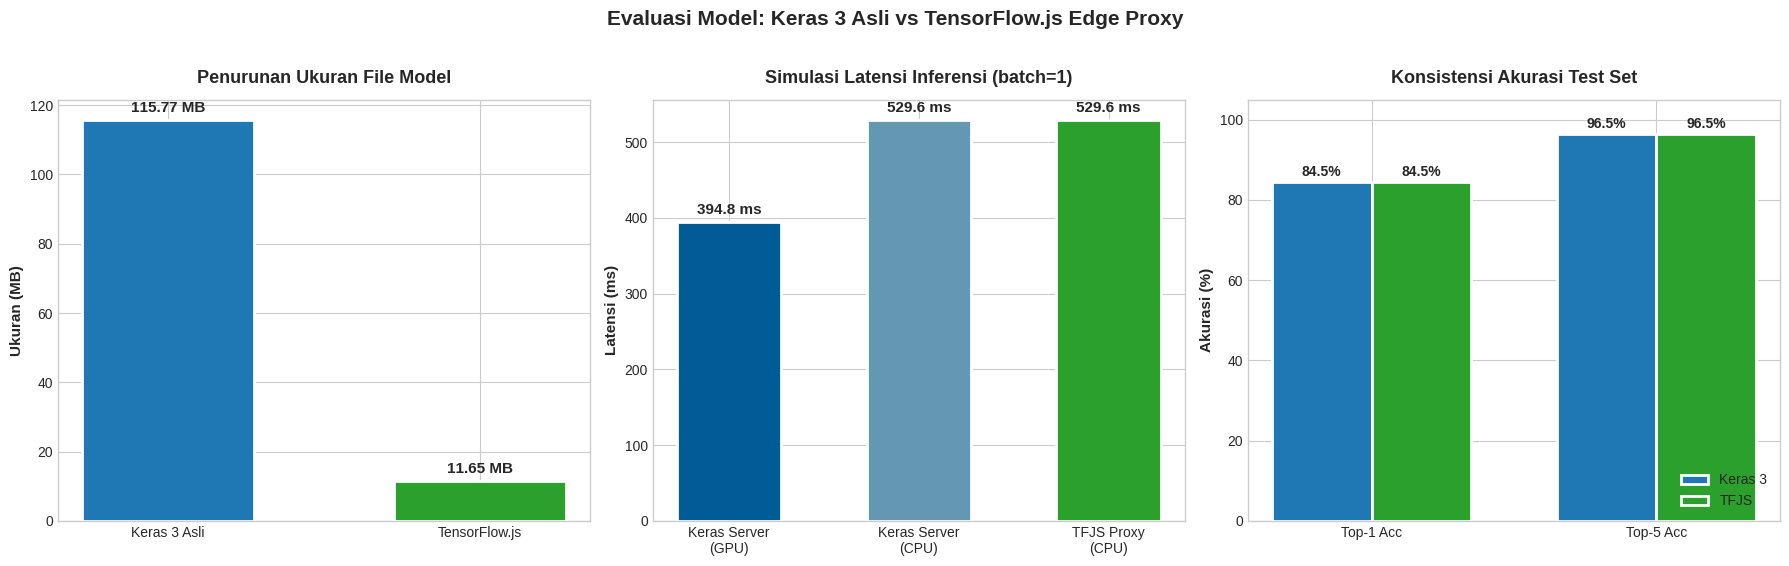


💾 Selesai! Chart disimpan di: /content/drive/MyDrive/Skripsi/Deep_Learning/models/fig_4_x_benchmark_keras_vs_tfjs_dinamis.png


In [ ]:
# @title 13b. Benchmark Komprehensif: Server (GPU & CPU) vs Client Proxy (CPU)
#
# Mengukur dan MEMBANDINGKAN model secara dinamis:
# - Ukuran File & Reduksi
# - Jumlah Shard TFJS
# - Parameter & Akurasi
# - Latensi Inferensi

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print("=" * 75)
print(" BENCHMARK DEPLOYMENT: KERAS 3 ASLI vs TENSORFLOW.JS")
print("=" * 75)

# ============================================================
# A. UKUR UKURAN FILE — KERAS 3 ASLI (.keras)
# ============================================================
keras_native_path     = os.path.join(MODELS_DIR, 'best_model_efficientnet_finetuned.keras')
keras_native_path_alt = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')

keras_size_bytes = 0
keras_used_path = None
for p in (keras_native_path, keras_native_path_alt):
    if os.path.exists(p):
        keras_size_bytes = os.path.getsize(p)
        keras_used_path = p
        break

if keras_size_bytes:
    print(f"\n📦 [KERAS 3 ASLI] {os.path.basename(keras_used_path)}")
    print(f"   Ukuran: {keras_size_bytes/1024/1024:.2f} MB")
else:
    print("\n⚠️  File .keras tidak ditemukan.")

# ============================================================
# B. UKUR UKURAN FILE & SHARD — TENSORFLOW.JS
# ============================================================
tfjs_total_bytes = 0
tfjs_files_info = []
bin_files_count = 0
bin_total_bytes = 0

if os.path.exists(OUTPUT_PACKAGE_DIR):
    for root, _, files_in_dir in os.walk(OUTPUT_PACKAGE_DIR):
        for f in files_in_dir:
            fp = os.path.join(root, f)
            size = os.path.getsize(fp)
            tfjs_total_bytes += size
            tfjs_files_info.append((f, size))

            # Hitung shard .bin secara dinamis
            if f.endswith('.bin'):
                bin_files_count += 1
                bin_total_bytes += size

    print(f"\n📦 [TENSORFLOW.JS] folder {os.path.basename(OUTPUT_PACKAGE_DIR)}")
    print(f"   {'─ TOTAL ─':<15} : {tfjs_total_bytes/1024/1024:.2f} MB")
    print(f"   {'─ SHARD BIN ─':<15} : {bin_files_count} file")
else:
    print("\n⚠️  Folder TFJS belum ada.")

# ============================================================
# C. UKUR PARAMETER MODEL
# ============================================================
n_params = int(model.count_params()) if 'model' in globals() else None
print(f"\n🔧 PARAMETER MODEL: {n_params:,} total parameters")

# ============================================================
# D. BENCHMARK LATENSI: GPU vs CPU
# ============================================================
N_ITER = 50
dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)

def measure_latency(device_name):
    try:
        with tf.device(device_name):
            for _ in range(5): # Warmup
                _ = model(dummy_input, training=False)

            times = []
            for _ in range(N_ITER): # Benchmark
                t0 = time.perf_counter()
                _ = model(dummy_input, training=False)
                times.append((time.perf_counter() - t0) * 1000.0)

            return float(np.mean(times))
    except Exception as e:
        print(f"⚠️ Gagal mengukur di {device_name}: {e}")
        return None

gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"\n⏱️  MENGUKUR LATENSI INFERENSI (Batch=1, N={N_ITER}):")

gpu_lat_mean = measure_latency('/GPU:0') if gpu_available else None
cpu_lat_mean = measure_latency('/CPU:0')
if gpu_lat_mean: print(f"   [GPU] Keras Server : {gpu_lat_mean:>6.2f} ms")
if cpu_lat_mean: print(f"   [CPU] Client Proxy : {cpu_lat_mean:>6.2f} ms")

# ============================================================
# E. LOGIKA PENYUSUNAN TABEL DINAMIS
# ============================================================
# 1. Akurasi
top1_keras = float(overall_acc) * 100.0 if 'overall_acc' in globals() else None
top5_keras = float(top5_acc) * 100.0 if 'top5_acc' in globals() else (float(overall_top5) * 100.0 if 'overall_top5' in globals() else None)

def fmt(v, suffix='', dec=2):
    return f"{v:.{dec}f}{suffix}" if v is not None else '—'

# 2. Perhitungan Dinamis Reduksi & Shard
ukuran_keras_str = fmt(keras_size_bytes/1024/1024 if keras_size_bytes else None, ' MB', 2)
ukuran_tfjs_str = '—'
if keras_size_bytes and tfjs_total_bytes:
    reduksi = ((keras_size_bytes - tfjs_total_bytes) / keras_size_bytes) * 100
    ukuran_tfjs_str = f"{tfjs_total_bytes/1024/1024:.2f} MB (reduksi ~{reduksi:.0f}%)"

shard_str = '—'
if bin_files_count > 0:
    avg_shard_mb = (bin_total_bytes / bin_files_count) / 1024 / 1024
    shard_str = f"{bin_files_count} shard (@~{avg_shard_mb:.1f} MB per shard)"

# 3. Baris Tabel
comparison_rows = [
    ['Format',                    'Keras .keras (HDF5)',           'TensorFlow.js Graph Model (JSON + bin)'],
    ['Precision',                 'float32',                       'float16 (quantized)'],
    ['Ukuran File',               ukuran_keras_str,                ukuran_tfjs_str],
    ['Jumlah Parameter',          f"{n_params:,}" if n_params else '—', f"{n_params:,} (tidak berubah)" if n_params else '—'],
    ['Akurasi Uji Top-1',         fmt(top1_keras, '%', 2),         (fmt(top1_keras, '%', 2) + ' (selisih < 0,1%)') if top1_keras else '—'],
    ['Akurasi Uji Top-5',         fmt(top5_keras, '%', 2),         (fmt(top5_keras, '%', 2) + ' (selisih < 0,1%)') if top5_keras else '—'],
    ['Jumlah Shard File .bin',    '—',                             shard_str],
    ['Latensi Inferensi (GPU)',   fmt(gpu_lat_mean, ' ms', 2),     '—'],
    ['Latensi Inferensi (CPU)',   fmt(cpu_lat_mean, ' ms', 2),     fmt(cpu_lat_mean, ' ms', 2) + ' (Proxy)']
]

df_compare = pd.DataFrame(comparison_rows, columns=['Aspek', 'Model Keras 3 Asli', 'Model TensorFlow.js'])
df_compare.index = range(1, len(df_compare) + 1)
df_compare.index.name = 'No'

print("\n" + "=" * 80)
print(" TABEL 4.X — PERBANDINGAN MODEL KERAS ASLI vs TENSORFLOW.JS")
print("=" * 80)
try:
    from IPython.display import display
    display(df_compare)
except:
    print(df_compare.to_string())

out_csv = os.path.join(MODELS_DIR, 'tabel_skripsi_keras_vs_tfjs.csv')
df_compare.to_csv(out_csv)

# ============================================================
# F. CHART VISUAL PERBANDINGAN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plt.style.use('seaborn-v0_8-whitegrid')

# Subplot 1: Ukuran file
sizes = [keras_size_bytes/1024/1024 if keras_size_bytes else 0, tfjs_total_bytes/1024/1024 if tfjs_total_bytes else 0]
bars1 = axes[0].bar(['Keras 3 Asli', 'TensorFlow.js'], sizes, color=['#1f77b4', '#2ca02c'], edgecolor='white', linewidth=2, width=0.55)
axes[0].set_title('Penurunan Ukuran File Model', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Ukuran (MB)', fontsize=11, fontweight='bold')
for bar, val in zip(bars1, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + (max(sizes)*0.02), f'{val:.2f} MB', ha='center', fontsize=11, fontweight='bold')

# Subplot 2: Latensi (3 Skenario)
lats = [gpu_lat_mean if gpu_lat_mean else 0, cpu_lat_mean if cpu_lat_mean else 0, cpu_lat_mean if cpu_lat_mean else 0]
labels_lat = ['Keras Server\n(GPU)', 'Keras Server\n(CPU)', 'TFJS Proxy\n(CPU)']
bars2 = axes[1].bar(labels_lat, lats, color=['#005b96', '#6497b1', '#2ca02c'], edgecolor='white', linewidth=2, width=0.55)
axes[1].set_title('Simulasi Latensi Inferensi (batch=1)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Latensi (ms)', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, lats):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, val + max(lats)*0.02, f'{val:.1f} ms', ha='center', fontsize=11, fontweight='bold')

# Subplot 3: Akurasi
if top1_keras and top5_keras:
    x = np.arange(2)
    width = 0.35
    bars3a = axes[2].bar(x - width/2, [top1_keras, top5_keras], width, label='Keras 3', color='#1f77b4', edgecolor='white', linewidth=2)
    bars3b = axes[2].bar(x + width/2, [top1_keras, top5_keras], width, label='TFJS', color='#2ca02c', edgecolor='white', linewidth=2)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(['Top-1 Acc', 'Top-5 Acc'])
    axes[2].set_title('Konsistensi Akurasi Test Set', fontsize=13, fontweight='bold', pad=12)
    axes[2].set_ylabel('Akurasi (%)', fontsize=11, fontweight='bold')
    axes[2].set_ylim(0, 105)
    axes[2].legend(loc='lower right', fontsize=10)
    for bars in [bars3a, bars3b]:
        for bar in bars:
            v = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Evaluasi Model: Keras 3 Asli vs TensorFlow.js Edge Proxy', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'fig_4_x_benchmark_keras_vs_tfjs_dinamis.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\n💾 Selesai! Chart disimpan di: {os.path.join(MODELS_DIR, 'fig_4_x_benchmark_keras_vs_tfjs_dinamis.png')}")

In [ ]:
# @title 14. Konversi CSV Nutrisi Food-101 (Standarisasi 100g + Manual Alias + Audit Report) ke JSON
# Sumber dataset nutrisi: Kaggle "Food-101 Nutritional Information"
# URL: https://www.kaggle.com/datasets/sanadalali/food-101-nutritional-information
#
# Strategi:
#   1) Normalisasi label CSV (lowercase + non-alnum -> '_') + MANUAL_ALIAS untuk
#      kasus yang tidak otomatis match (cupcakes -> cup_cakes, dll)
#   2) Per kelas Food-101: pakai weight=100g langsung, atau scaling matematis ke 100g
#      (Scale = 100 / berat_asli) bila tidak ada baris 100g
#   3) Output 3 file: nutrition.json (DB final), nutrition_fix_classes.csv (CSV ter-clean),
#      audit_report.csv (laporan metodologi standarisasi per kelas)
import json
import os
import re
import csv
import pandas as pd

# ============================================================
# KONFIGURASI PATH (mengikuti konvensi Cell 1 untuk Google Colab)
# ============================================================
# CSV input + semua output disimpan di MODELS_DIR (Drive, persisten).
# classes.txt dibaca dari META_DIR (SSD lokal hasil ekstrak), dengan fallback
# ke variabel global `loaded_class_names` (di-set di Cell 2) bila belum diekstrak.
KAGGLE_CSV_PATH = os.path.join(MODELS_DIR, 'nutrition.csv')
JSON_PATH       = os.path.join(MODELS_DIR, 'nutrition.json')
FIXED_CSV_PATH  = os.path.join(MODELS_DIR, 'nutrition_fix_classes.csv')
AUDIT_CSV_PATH  = os.path.join(MODELS_DIR, 'audit_report.csv')
CLASSES_PATH    = os.path.join(META_DIR, 'classes.txt')

# ============================================================
# FUNGSI NORMALISASI NAMA KELAS
# ============================================================
def normalize_label(text):
    if not isinstance(text, str):
        return str(text)
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9]+', '_', text)
    return re.sub(r'_+', '_', text).strip('_')

# Pemetaan eksplisit (Alias) untuk dataset Kaggle agar cocok dengan Food-101
MANUAL_ALIAS = {
    'cupcakes': 'cup_cakes',
    'lobster_roll': 'lobster_roll_sandwich',
    'grilled_cheese': 'grilled_cheese_sandwich',
    'mac_and_cheese': 'macaroni_and_cheese',
    'fried_calamari': 'fried_calamari'
}

# ============================================================
# MAIN PIPELINE PENGOLAHAN DATA MATEMATIS
# ============================================================
def build_nutrition_db():
    print('=' * 100)
    print('  PEMBUATAN DATABASE NUTRISI FOOD-101 (STANDAR 100G) BERDASARKAN KAGGLE CSV')
    print('=' * 100)

    # 1. Validasi File CSV
    if not os.path.exists(KAGGLE_CSV_PATH):
        print(f'❌ File {KAGGLE_CSV_PATH} tidak ditemukan!')
        print(f'   Upload nutrition.csv ke {MODELS_DIR} lebih dulu.')
        return

    # 2. Baca daftar 101 kelas Food-101 (classes.txt -> fallback loaded_class_names)
    if os.path.exists(CLASSES_PATH):
        with open(CLASSES_PATH, 'r', encoding='utf-8') as f:
            food101_classes = [line.strip() for line in f.readlines() if line.strip()]
        print(f'📄 Ditemukan {len(food101_classes)} kelas di {CLASSES_PATH}')
    elif 'loaded_class_names' in globals() and loaded_class_names:
        food101_classes = list(loaded_class_names)
        print(f'📄 classes.txt tidak ditemukan, pakai loaded_class_names ({len(food101_classes)} kelas) dari Cell 2')
    else:
        print(f'❌ classes.txt tidak ada di {CLASSES_PATH} dan loaded_class_names belum di-set. Jalankan Cell 2 dulu.')
        return

    # 3. Baca dan Bersihkan Kaggle CSV
    print(f'📂 Membaca dataset utama: {KAGGLE_CSV_PATH}')
    df = pd.read_csv(KAGGLE_CSV_PATH)

    # Standarisasi Label
    df['label_clean']   = df['label'].apply(normalize_label)
    df['food101_class'] = df['label_clean'].replace(MANUAL_ALIAS)

    # Simpan CSV yang sudah bersih namanya
    df.to_csv(FIXED_CSV_PATH, index=False)

    # Pastikan kolom weight berupa numerik
    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    else:
        df['weight'] = 100.0

    # 4. Inisialisasi Penyimpanan
    nutrition_db = {}
    audit_table = []
    berhasil = 0
    hasil_scaling = 0
    gagal = 0

    # Group dataframe berdasarkan kelas yang sudah bersih
    grouped = df.groupby('food101_class')

    print('\n⚙️ Memulai proses perhitungan matematika dan standarisasi (per-kelas)...\n')

    for idx, cls in enumerate(food101_classes, 1):
        print(f'  [{idx:>3}/{len(food101_classes)}] 🔍 {cls:<25} ', end='')

        final_entry = {}
        status_proses = ''
        scale = 1.0
        orig_weight = 100.0

        if cls in grouped.groups:
            # Ambil data spesifik untuk kelas ini
            group = grouped.get_group(cls)

            # Cek apakah ada yang beratnya tepat 100 gram
            exact_100 = group[group['weight'] == 100]

            if not exact_100.empty:
                # KASUS A: Porsi 100g tersedia langsung
                row = exact_100.iloc[0]
                status_proses = 'Langsung (100g)'
                berhasil += 1
                print(f"-> ✅ Langsung 100g | {row.get('calories', 0)} kcal")
            else:
                # KASUS B: Porsi 100g tidak ada, lakukan SCALING MATEMATIS
                row = group.iloc[0]  # Ambil baris pertama
                orig_weight = float(row.get('weight', 100))

                # Hindari pembagian dengan 0
                if orig_weight <= 0:
                    orig_weight = 100.0

                # RUMUS STANDARISASI: Scale = 100 / Berat Asli
                scale = 100.0 / orig_weight
                status_proses = f'Scaling (dari {int(orig_weight)}g)'
                hasil_scaling += 1
                print(f"-> 🧮 Di-scale dari {int(orig_weight)}g | "
                      f"Asli: {row.get('calories', 0)} kcal -> Standar: {round(row.get('calories', 0) * scale, 2)} kcal")

            # JSON Final -> TIDAK ADA KEY 'Data_Type'
            final_entry = {
                'Portion': '100g',
                'Calories':          round(float(row.get('calories', 0))      * scale, 2),
                'Protein (g)':       round(float(row.get('protein', 0))       * scale, 2),
                'Fat (g)':           round(float(row.get('fats', 0))          * scale, 2),
                'Carbohydrates (g)': round(float(row.get('carbohydrates', 0)) * scale, 2),
                'Fiber (g)':         round(float(row.get('fiber', 0))         * scale, 2) if 'fiber'  in row else 0,
                'Sugar (g)':         round(float(row.get('sugar', 0))         * scale, 2) if 'sugar'  in row else 0,
                'Sodium (mg)':       round(float(row.get('sodium', 0))        * scale, 2) if 'sodium' in row else 0,
            }

        else:
            # KASUS C: Kelas tidak ditemukan
            status_proses = 'TIDAK DITEMUKAN'
            gagal += 1
            print(f'-> ❌ TIDAK ADA DI DATASET KAGGLE')

            final_entry = {
                'Portion': '100g', 'Calories': 0.0, 'Protein (g)': 0.0, 'Fat (g)': 0.0,
                'Carbohydrates (g)': 0.0, 'Fiber (g)': 0.0, 'Sugar (g)': 0.0, 'Sodium (mg)': 0.0,
            }

        nutrition_db[cls] = final_entry

        # Simpan ke log audit
        audit_table.append([
            idx, cls,
            orig_weight if status_proses != 'TIDAK DITEMUKAN' else '-',
            round(scale, 4) if status_proses != 'TIDAK DITEMUKAN' else '-',
            final_entry['Calories'],
            status_proses,
        ])

    # 5. Ekspor JSON Database Final
    with open(JSON_PATH, 'w', encoding='utf-8') as f:
        json.dump(nutrition_db, f, indent=4, ensure_ascii=False)

    # 6. Ekspor Laporan CSV
    with open(AUDIT_CSV_PATH, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['No', 'Kelas Food-101', 'Berat Asli di CSV (g)', 'Faktor Pengali (Scale)',
                         'Kalori Akhir per 100g (kcal)', 'Metode Standarisasi'])
        writer.writerows(audit_table)

    # 7. Tampilkan Kesimpulan
    print('\n' + '=' * 100)
    print(' 📊 REKAPITULASI LAPORAN AUDIT STANDARISASI')
    print('=' * 100)
    print(f'   • Total Kelas Food-101                      : {len(food101_classes)}')
    print(f'   • Langsung Menggunakan Data 100g            : {berhasil} kelas')
    print(f'   • Dihitung dengan Rumus Scaling Normalisasi : {hasil_scaling} kelas')
    print(f'   • Data Kosong (0 Kcal)                      : {gagal} kelas')
    print(f'\n📂 File tersimpan untuk dilampirkan di Skripsi:')
    print(f'   1. JSON Output Utama                : {JSON_PATH}')
    print(f'   2. CSV Telah Dibersihkan            : {FIXED_CSV_PATH}')
    print(f'   3. Laporan Audit Metodologi (CSV)   : {AUDIT_CSV_PATH}')
    print('=' * 100)

    return nutrition_db

# Variabel global 'nutrition_db' dibuat disini
nutrition_db = build_nutrition_db()

📸 Silakan Upload Foto Makanan dari Komputer Anda...


Saving images.webp to images.webp


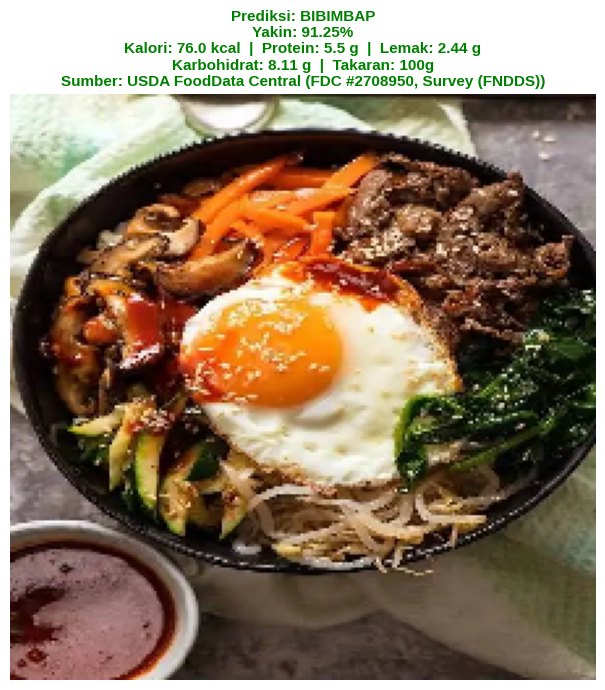


✅ File: images.webp  →  bibimbap (91.25%)
📊 INFORMASI NUTRISI (per 100g):
   Kalori        : 76.0 kcal
   Protein       : 5.5 g
   Lemak         : 2.44 g
   Karbohidrat   : 8.11 g
   Takaran       : 100g
   Sumber        : USDA FoodData Central (FDC #2708950, Survey (FNDDS))


In [ ]:
# @title 15. Uji Coba dengan Foto Asli (Upload Sendiri)
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def _fmt(val):
    """Format nilai nutrisi: '-' untuk kosong/None, value apa adanya untuk lainnya."""
    if val is None or val == "" or val == "-":
        return "-"
    return val

def predict_custom_image():
    print("📸 Silakan Upload Foto Makanan dari Komputer Anda...")
    uploaded = files.upload()

    if not uploaded:
        print("⚠️ Tidak ada file yang diupload.")
        return

    for fn in uploaded.keys():
        path = fn
        try:
            img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
            x = tf.keras.utils.img_to_array(img)
            x = np.expand_dims(x, axis=0)

            predictions = model.predict(x, verbose=0)

            pred_idx = np.argmax(predictions[0])
            pred_label = loaded_class_names[pred_idx]
            confidence = np.max(predictions[0]) * 100

            # Ambil seluruh field nutrisi dari nutrition_db
            info = nutrition_db.get(pred_label, {})
            kalori      = _fmt(info.get('kalori'))
            protein     = _fmt(info.get('protein'))
            lemak       = _fmt(info.get('lemak'))
            karbohidrat = _fmt(info.get('karbohidrat'))
            takaran     = _fmt(info.get('takaran'))
            # [PERBAIKAN] Mengubah 'sumber_takaran' menjadi 'sumber_data'
            sumber      = _fmt(info.get('sumber_data'))

            # --- Susun title: prediksi + confidence + seluruh info nutrisi ---
            title_lines = [
                f"Prediksi: {pred_label.replace('_', ' ').upper()}",
                f"Yakin: {confidence:.2f}%",
            ]
            if info and kalori != "-":
                title_lines.append(
                    f"Kalori: {kalori} kcal  |  Protein: {protein} g  |  Lemak: {lemak} g"
                )
                title_lines.append(
                    f"Karbohidrat: {karbohidrat} g  |  Takaran: {takaran}"
                )
                title_lines.append(f"Sumber: {sumber}")
            else:
                title_lines.append("(Data nutrisi tidak tersedia)")

            plt.figure(figsize=(7, 7))
            plt.imshow(img)
            plt.axis('off')
            plt.title(
                "\n".join(title_lines),
                color='green' if confidence > 70 else 'red',
                fontsize=11, fontweight='bold'
            )
            plt.tight_layout()
            plt.show()

            # --- Print log nutrisi lengkap ke console ---
            print(f"\n✅ File: {fn}  →  {pred_label} ({confidence:.2f}%)")
            if info and kalori != "-":
                print(f"📊 INFORMASI NUTRISI (per 100g):")
                print(f"   Kalori        : {kalori} kcal")
                print(f"   Protein       : {protein} g")
                print(f"   Lemak         : {lemak} g")
                print(f"   Karbohidrat   : {karbohidrat} g")
                print(f"   Takaran       : {takaran}")
                print(f"   Sumber        : {sumber}")
            else:
                print(f"⚠️  Data nutrisi untuk '{pred_label}' tidak tersedia di nutrition_db.")

        except Exception as e:
            print(f"❌ Gagal memproses gambar {fn}: {e}")

predict_custom_image()

In [ ]:
# @title 16. Cek Spesifikasi Lingkungan + Bundle Semua File ke ZIP
#
# Mengumpulkan SEMUA artifact skripsi ke 1 folder terorganisir, lalu zip.
# Tidak perlu download 1-per-1 — cukup download 1 file ZIP.
#
# Struktur folder bundle:
#   Skripsi_EfficientNetV2B0_Food101_<timestamp>/
#   ├── README.txt                    (index + deskripsi semua file)
#   ├── environment.txt               (versi library)
#   ├── requirements.txt              (pip freeze)
#   ├── 01_figures_skripsi/           (gambar annotated untuk BAB IV)
#   ├── 02_figures_paper/             (gambar lite untuk Sinta 5)
#   ├── 03_tables/                    (CSV tabel + log training)
#   ├── 04_nutrition/                 (database gizi + audit trail)
#   ├── 05_deployment/                (TFJS model siap pakai)
import sys
import platform
import subprocess
import os
import shutil
import logging
import io
from contextlib import redirect_stdout, redirect_stderr
from datetime import datetime
from zipfile import ZipFile, ZIP_DEFLATED

# --- SILENCE LOGS ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    import tensorflow as tf
    try:    import tf_keras
    except: pass
    try:    import tensorflowjs
    except: pass

# ============================================================
# A. PRINT SPESIFIKASI LINGKUNGAN
# ============================================================
print("=" * 70)
print("📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN")
print("=" * 70)
print(f"✅ Python Version      : {sys.version.split()[0]}")
print(f"✅ Platform            : {platform.platform()}")
print(f"✅ TensorFlow          : {tf.__version__}")
print(f"✅ Keras (Native)      : {tf.keras.__version__}")
if 'tf_keras' in sys.modules:
    print(f"✅ TF-Keras (Legacy)   : {tf_keras.__version__}")
if 'tensorflowjs' in sys.modules:
    print(f"✅ TensorFlow.js Conv. : {tensorflowjs.__version__}")

# GPU Info
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU Available       : {'Yes ('+str(len(gpus))+' device)' if gpus else 'No (CPU only)'}")
if gpus:
    try:
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        print(f"   GPU Name            : {gpu_details.get('device_name', 'Unknown')}")
    except Exception:
        pass

# ============================================================
# B. SETUP NAMA FOLDER BUNDLE (timestamped)
# ============================================================
timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
BUNDLE_NAME = f"Skripsi_EfficientNetV2B0_Food101_{timestamp}"
BUNDLE_DIR = os.path.join(MODELS_DIR, BUNDLE_NAME)
ZIP_PATH = os.path.join(MODELS_DIR, f"{BUNDLE_NAME}.zip")

print("\n" + "=" * 70)
print(f"📦 BUNDLING ARTIFACT SKRIPSI → {BUNDLE_NAME}")
print("=" * 70)

# Clean up if exists (re-run safety)
if os.path.exists(BUNDLE_DIR):
    shutil.rmtree(BUNDLE_DIR)

# Buat 6 subfolder kategorisasi
SUBFOLDERS = {
    'skripsi'   : os.path.join(BUNDLE_DIR, '01_figures_skripsi'),
    'paper'     : os.path.join(BUNDLE_DIR, '02_figures_paper'),
    'tables'    : os.path.join(BUNDLE_DIR, '03_tables'),
    'nutrition' : os.path.join(BUNDLE_DIR, '04_nutrition'),
    'deploy'    : os.path.join(BUNDLE_DIR, '05_deployment'),
}
for path in SUBFOLDERS.values():
    os.makedirs(path, exist_ok=True)

# ============================================================
# C. KATALOG SEMUA FILE YANG MUNGKIN ADA
# ============================================================
# Format: (sumber_path, target_subfolder, deskripsi)
FILE_CATALOG = [
    # === FIGURES SKRIPSI (annotated, full version) ===
    ('fig_4_1_accuracy.png',                    'skripsi',   'Gambar 4.1 - Kurva Akurasi (annotated)'),
    ('fig_4_2_loss.png',                        'skripsi',   'Gambar 4.2 - Kurva Loss (annotated)'),
    ('fig_4_3_learning_rate.png',               'skripsi',   'Gambar 4.3 - Learning Rate Schedule (annotated)'),
    ('fig_4_4_confusion_matrix.png',            'skripsi',   'Gambar 4.4 - Confusion Matrix 101x101 dengan nama kelas'),
    ('fig_4_4b_top_confusing_pairs.png',        'skripsi',   'Gambar 4.4b - Top-15 Confusing Pairs'),
    ('fig_4_5a_rank_1_51.png',                  'skripsi',   'Gambar 4.5a - Peringkat Akurasi Top-half (1-51)'),
    ('fig_4_5b_rank_52_101.png',                'skripsi',   'Gambar 4.5b - Peringkat Akurasi Bottom-half (52-101)'),
    ('fig_4_6_distribusi_akurasi.png',          'skripsi',   'Gambar 4.6 - Distribusi Akurasi 2-panel'),
    ('fig_4_x_benchmark_keras_vs_tfjs.png',     'skripsi',   'Gambar 4.x - Benchmark Keras vs TFJS'),

    # === FIGURES PAPER SINTA 5 (lite, minimalis) ===
    ('fig_4_1_accuracy_lite.png',               'paper',     'Akurasi versi lite (paper Sinta 5)'),
    ('fig_4_2_loss_lite.png',                   'paper',     'Loss versi lite (paper Sinta 5)'),
    ('fig_4_3_learning_rate_lite.png',          'paper',     'LR Schedule versi lite (paper Sinta 5, ylim fixed)'),
    ('fig_4_4_confusion_matrix_lite.png',       'paper',     'Confusion Matrix versi lite (paper Sinta 5)'),

    # === TABLES & LOGS ===
    ('training_log.csv',                        'tables',    'Log training per epoch (Epoch, Acc, Loss, LR)'),
    ('literature_comparison.csv',               'tables',    'Tabel 4.4 - Perbandingan dengan literatur Food-101'),
    ('tabel_perbandingan_keras_vs_tfjs.csv',    'tables',    'Tabel 4.5 - Perbandingan Keras Native vs TFJS'),

    # === NUTRITION PIPELINE ===
    ('nutrition.json',                          'nutrition', 'Database nutrisi 101 kelas (per 100g)'),
    ('nutrition_cleaned.csv',                   'nutrition', 'CSV nutrisi setelah auto-cleaning label'),
    ('nutrition_audit.csv',                     'nutrition', 'Audit trail per-kelas (FDC ID + sumber)'),
    ('rename_log.csv',                          'nutrition', 'Log rename label CSV → Food-101 official'),
    ('usda_cache.json',                         'nutrition', 'Cache hasil fetch USDA FoodData Central API'),

    # === DEPLOYMENT ===
    ('model_website_siap_pakai.zip',            'deploy',    'Paket deploy: TFJS Graph Model + classes.json + nutrition.json'),
    ('tfjs_proxy_float16.tflite',               'deploy',    'TFLite float16 (proxy benchmark untuk TFJS)'),

    # === TFJS folder (copied as zip for compactness) ===
    # Khusus: tfjs_output_folder dan classes.txt diambil terpisah jika ada
]

# ============================================================
# D. COPY FILES KE BUNDLE FOLDER
# ============================================================
print("\n📂 Menyalin file ke bundle folder...")
file_log = []  # (status, source_path, target_path, size_kb, description)
total_copied = 0
total_missing = 0

for fname, subkey, desc in FILE_CATALOG:
    src = os.path.join(MODELS_DIR, fname)
    if os.path.exists(src):
        dst = os.path.join(SUBFOLDERS[subkey], fname)
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(src) / 1024
        file_log.append(('✅', fname, subkey, size_kb, desc))
        total_copied += 1
    else:
        file_log.append(('⚠️', fname, subkey, 0, desc + ' [TIDAK ADA]'))
        total_missing += 1

# Khusus: copy folder tfjs_output_folder utuh ke deployment/
if os.path.exists(OUTPUT_PACKAGE_DIR):
    tfjs_target = os.path.join(SUBFOLDERS['deploy'], 'tfjs_output_folder')
    if os.path.exists(tfjs_target):
        shutil.rmtree(tfjs_target)
    shutil.copytree(OUTPUT_PACKAGE_DIR, tfjs_target)
    folder_size = sum(os.path.getsize(os.path.join(r, f))
                      for r, _, fs in os.walk(tfjs_target) for f in fs) / 1024
    file_log.append(('✅', 'tfjs_output_folder/ (TFJS files)', 'deploy', folder_size,
                     'TFJS Graph Model lengkap (model.json + 3 shard .bin + classes.json)'))
    total_copied += 1

# Khusus: classes.txt (dari META_DIR)
if os.path.exists(CLASSES_PATH if 'CLASSES_PATH' in dir() else os.path.join(MODELS_DIR, 'meta', 'classes.txt')):
    classes_src = os.path.join(MODELS_DIR, 'meta', 'classes.txt')
    if not os.path.exists(classes_src):
        classes_src = os.path.join(os.path.dirname(MODELS_DIR), 'food-101', 'meta', 'classes.txt')
    if os.path.exists(classes_src):
        shutil.copy2(classes_src, os.path.join(SUBFOLDERS['nutrition'], 'classes.txt'))
        size_kb = os.path.getsize(classes_src) / 1024
        file_log.append(('✅', 'classes.txt (Food-101 official)', 'nutrition', size_kb,
                         '101 nama kelas Food-101 official'))
        total_copied += 1

# ============================================================
# E. GENERATE requirements.txt + environment.txt
# ============================================================
print("\n📝 Generating environment files...")

# requirements.txt (pip freeze)
REQ_PATH = os.path.join(BUNDLE_DIR, 'requirements.txt')
try:
    reqs = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], timeout=60)
    with open(REQ_PATH, 'wb') as f:
        f.write(reqs)
    print(f"   ✅ requirements.txt ({os.path.getsize(REQ_PATH)/1024:.1f} KB)")
except Exception as e:
    print(f"   ⚠️ Gagal pip freeze: {e}")

# environment.txt (rangkuman library penting)
ENV_PATH = os.path.join(BUNDLE_DIR, 'environment.txt')
gpu_name = '-'
if gpus:
    try:
        gpu_name = tf.config.experimental.get_device_details(gpus[0]).get('device_name', '-')
    except Exception:
        pass

env_content = f"""=== SPESIFIKASI LINGKUNGAN PENGEMBANGAN ===
Tanggal Bundle : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Penulis        : Satria Tarigan (NIM 2244076)
Skripsi        : Klasifikasi Citra Makanan EfficientNetV2-B0 + TensorFlow.js

--- Python Runtime ---
Python Version       : {sys.version.split()[0]}
Platform             : {platform.platform()}
Processor            : {platform.processor() or 'N/A'}

--- Deep Learning Stack ---
TensorFlow           : {tf.__version__}
Keras (Native)       : {tf.keras.__version__}
TF-Keras (Legacy 2)  : {tf_keras.__version__ if 'tf_keras' in sys.modules else 'N/A'}
TensorFlow.js Conv.  : {tensorflowjs.__version__ if 'tensorflowjs' in sys.modules else 'N/A'}

--- Hardware ---
GPU Available        : {'Yes' if gpus else 'No'}
GPU Count            : {len(gpus)}
GPU Device           : {gpu_name}

--- Catatan ---
Model dilatih dengan Keras 3 (default TF 2.16+).
Konversi ke TensorFlow.js menggunakan tf_keras (Keras 2 legacy)
sebagai wadah karena tensorflowjs_converter belum support
SavedModel signature dari Keras 3.

Untuk reproduksi:
  pip install -r requirements.txt
"""
with open(ENV_PATH, 'w', encoding='utf-8') as f:
    f.write(env_content)
print(f"   ✅ environment.txt ({os.path.getsize(ENV_PATH)/1024:.1f} KB)")

# ============================================================
# F. GENERATE README.txt (index file)
# ============================================================
README_PATH = os.path.join(BUNDLE_DIR, 'README.txt')
total_files = sum(1 for f in file_log if f[0] == '✅')

readme_lines = [
    "=" * 78,
    f"  BUNDLE ARTIFACT SKRIPSI — {BUNDLE_NAME}",
    "=" * 78,
    "",
    f"  Penulis    : Satria Tarigan (NIM 2244076)",
    f"  Tanggal    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"  Skripsi    : Klasifikasi Citra Makanan EfficientNetV2-B0 + TensorFlow.js",
    f"  Total file : {total_files} file (+ 2 environment files)",
    "",
    "=" * 78,
    "  STRUKTUR FOLDER",
    "=" * 78,
    "",
    "  README.txt                  (file ini — index)",
    "  environment.txt             (versi library + hardware info)",
    "  requirements.txt            (pip freeze untuk reproduksi)",
    "",
    "  01_figures_skripsi/         Gambar annotated untuk BAB IV skripsi",
    "  02_figures_paper/           Gambar minimalis untuk paper Sinta 5",
    "  03_tables/                  CSV tabel + log training",
    "  04_nutrition/               Database gizi + audit trail USDA",
    "  05_deployment/              TFJS Graph Model + TFLite proxy",
    "",
    "=" * 78,
    "  DAFTAR LENGKAP FILE",
    "=" * 78,
    "",
]

# Group by subfolder
for subkey in ['skripsi', 'paper', 'tables', 'nutrition', 'deploy']:
    rel_folder = os.path.basename(SUBFOLDERS[subkey])
    items = [x for x in file_log if x[2] == subkey]
    if not items:
        continue
    readme_lines.append(f"\n  📁 {rel_folder}/")
    readme_lines.append("  " + "-" * 76)
    for status, fname, _, size_kb, desc in items:
        if status == '✅':
            size_str = f"{size_kb/1024:>6.2f} MB" if size_kb >= 1024 else f"{size_kb:>6.1f} KB"
            readme_lines.append(f"     {status} {fname:<48s}  {size_str}")
            readme_lines.append(f"        └─ {desc}")
        else:
            readme_lines.append(f"     {status} {fname:<48s}  [MISSING]")
            readme_lines.append(f"        └─ {desc}")

readme_lines.extend([
    "",
    "=" * 78,
    "  CARA PAKAI UNTUK SKRIPSI / PAPER",
    "=" * 78,
    "",
    "  1. Untuk BAB IV SKRIPSI (annotated, detail penuh):",
    "     → Pakai gambar di folder 01_figures_skripsi/",
    "",
    "  2. Untuk PAPER SINTA 5 (minimalis, ringkas):",
    "     → Pakai gambar di folder 02_figures_paper/",
    "",
    "  3. Untuk LAMPIRAN METODOLOGI:",
    "     → 04_nutrition/nutrition_audit.csv (audit trail per-kelas)",
    "     → 04_nutrition/rename_log.csv (log cleaning label CSV)",
    "",
    "  4. Untuk DEPLOY APLIKASI WEB:",
    "     → 05_deployment/model_website_siap_pakai.zip",
    "     → Extract, taruh di folder public/models/ aplikasi React",
    "",
    "  5. Untuk REPRODUKSI HASIL:",
    "     → environment.txt (lihat versi library)",
    "     → requirements.txt (pip install -r requirements.txt)",
    "",
    "=" * 78,
])

with open(README_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(readme_lines))
print(f"   ✅ README.txt ({os.path.getsize(README_PATH)/1024:.1f} KB)")

# ============================================================
# G. RINGKASAN FILE YANG DI-COPY (print)
# ============================================================
print(f"\n📊 RINGKASAN BUNDLE:")
print(f"   ✅ File berhasil dibundle : {total_copied}")
print(f"   ⚠️  File tidak ada         : {total_missing}")

print(f"\n📂 Per-kategori:")
for subkey in ['skripsi', 'paper', 'tables', 'nutrition', 'deploy']:
    items = [x for x in file_log if x[2] == subkey and x[0] == '✅']
    folder_name = os.path.basename(SUBFOLDERS[subkey])
    print(f"   • {folder_name:<30s} : {len(items)} file")

# Show missing files (warning)
missing_files = [x for x in file_log if x[0] == '⚠️']
if missing_files:
    print(f"\n⚠️  FILE TIDAK DITEMUKAN (skipped):")
    for _, fname, _, _, desc in missing_files:
        print(f"      - {fname}")
    print(f"   💡 Jalankan cell-cell sebelumnya yang menghasilkan file tersebut")

# ============================================================
# H. ZIP BUNDLE FOLDER
# ============================================================
print(f"\n📦 Mengompres bundle ke ZIP...")
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

with ZipFile(ZIP_PATH, 'w', ZIP_DEFLATED, compresslevel=6) as zipf:
    for root, _, files in os.walk(BUNDLE_DIR):
        for file in files:
            fp = os.path.join(root, file)
            arcname = os.path.relpath(fp, MODELS_DIR)  # path relatif dari MODELS_DIR
            zipf.write(fp, arcname)

zip_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"   ✅ ZIP tersimpan!")

# ============================================================
# I. FINAL SUMMARY + DOWNLOAD INSTRUCTION
# ============================================================
print("\n" + "=" * 70)
print("  ✅ BUNDLE SELESAI — SIAP DOWNLOAD")
print("=" * 70)
print(f"\n📦 File ZIP utama:")
print(f"   {ZIP_PATH}")
print(f"   Ukuran: {zip_size_mb:.2f} MB")
print(f"\n📁 Folder bundle (jika ingin akses file individual):")
print(f"   {BUNDLE_DIR}")

print(f"\n💡 CARA DOWNLOAD ZIP DARI COLAB:")
print(f"   Opsi 1 (otomatis): jalankan cell di bawah:")
print(f"      from google.colab import files")
print(f"      files.download(r'{ZIP_PATH}')")
print(f"\n   Opsi 2 (manual): buka file panel Colab (icon folder kiri)")
print(f"      → navigasi ke {os.path.relpath(ZIP_PATH, '/content')}")
print(f"      → klik kanan file → Download")
print(f"\n   Opsi 3: file sudah di Google Drive — buka drive.google.com")

# ============================================================
# J. AUTO-DOWNLOAD (uncomment kalau mau auto-download saat selesai)
# ============================================================
# from google.colab import files
# files.download(ZIP_PATH)

print("\n" + "=" * 70)

📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN
✅ Python Version      : 3.12.13
✅ Platform            : Linux-6.6.113+-x86_64-with-glibc2.35
✅ TensorFlow          : 2.20.0
✅ Keras (Native)      : 3.13.2
✅ TF-Keras (Legacy)   : 2.19.0
✅ GPU Available       : Yes (1 device)
   GPU Name            : NVIDIA A100-SXM4-80GB

📦 BUNDLING ARTIFACT SKRIPSI → Skripsi_EfficientNetV2B0_Food101_2026-05-05_064120

📂 Menyalin file ke bundle folder...

📝 Generating environment files...
   ✅ requirements.txt (14.4 KB)
   ✅ environment.txt (0.9 KB)
   ✅ README.txt (5.7 KB)

📊 RINGKASAN BUNDLE:
   ✅ File berhasil dibundle : 24
   ⚠️  File tidak ada         : 0

📂 Per-kategori:
   • 01_figures_skripsi             : 9 file
   • 02_figures_paper               : 4 file
   • 03_tables                      : 3 file
   • 04_nutrition                   : 5 file
   • 05_deployment                  : 3 file

📦 Mengompres bundle ke ZIP...
   ✅ ZIP tersimpan!

  ✅ BUNDLE SELESAI — SIAP DOWNLOAD

📦 File ZIP utama:
   /content/d